# PM2.5 True Multi-Step Forecasting with LSTM and GRU
Tuned 7-Day, 14-Day and 30-Day Forecasts

###  comparison experiment

This notebook tests whether using a longer historical **input window** improves or worsens **next-day PM2.5 prediction**.

**Important distinction:**
- 7-day, 14-day and 30-day are now **look-back/input windows**.
- The target is always **the next day's PM2.5 value**.
- Therefore this notebook does **not** claim that 7/14/30 are future forecast horizons.
- This provides a fair next-day baseline and evidence for how the amount of historical context affects performance.

All evaluation metrics are calculated after converting predictions back to the **original PM2.5 scale**, so they are directly interpretable and comparable with other models.

This first section sets up our working environment. We import all the necessary libraries like `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, `sklearn` for data scaling and metrics, and `tensorflow` for building our deep learning models. We also set a random seed to ensure that our results are reproducible every time we run the notebook, making our experiments consistent.

In [1]:
# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Here, we define important settings and parameters for our experiment. This includes the path to our data file, the name of the column we want to predict (our target, 'pm25'), and the different lengths of historical data ('look-back windows') we'll use for our models (7, 14, and 30 days). We also set ratios for splitting our data into training, validation, and test sets, and define the range of hyperparameters we'll explore for tuning our LSTM and GRU models. These configurations ensure our experiment is structured and systematic.

In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

FILE_PATH = "/content/marylebone_train.csv"

# Change this only if the target column has a different name.
TARGET = "pm25"

# These are INPUT WINDOWS, not forecast horizons.
LOOK_BACKS = [7, 14, 30]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

MAX_EPOCHS = 100
PATIENCE = 10

# Hyperparameter search
PARAM_GRID = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}

# None = complete grid.
# Set to a small integer temporarily if you only want a quick test.
MAX_CONFIGS = None

print("Input windows:", LOOK_BACKS)
print("Forecast target: next day only")
print("Full configurations per model/window:",
      np.prod([len(v) for v in PARAM_GRID.values()]))

Input windows: [7, 14, 30]
Forecast target: next day only
Full configurations per model/window: 16


In this part, we load our raw PM2.5 data from the specified CSV file into a pandas DataFrame. We then perform some initial cleaning steps: converting the 'date' column to a proper datetime format, handling any missing values by filling them in, and ensuring our target 'pm25' column is numeric. Finally, we display the first few rows of the cleaned data (`df.head()`) to get a quick overview and confirm that the data looks correct, along with its shape and date range.

In [3]:
# ============================================================
# 3. LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv(FILE_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

if TARGET not in df.columns:
    # Helpful fallback if the exact column name differs.
    possible = [c for c in df.columns if c.lower() in ["pm2.5", "pm25", "pm_25"]]
    if possible:
        TARGET = possible[0]
    else:
        raise ValueError(
            f"Could not find '{TARGET}'. Available columns: {df.columns.tolist()}"
        )

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols] = df[numeric_cols].ffill().bfill()
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Target:", TARGET)
print("Date range:", df["date"].min(), "to", df["date"].max())

display(df.head())

Dataset shape: (1000, 42)
Target: pm25
Date range: 2022-04-07 00:00:00 to 2024-12-31 00:00:00


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


For time series forecasting, it's crucial to split our data chronologically to prevent 'data leakage' (where future information accidentally influences the model). In this section, we divide our dataset into three parts: a training set (70% of the data) to teach the models, a validation set (15%) to tune hyperparameters, and a test set (15%) to evaluate the final, unseen performance. We print the date ranges for each split to ensure they are sequential and non-overlapping.

In [4]:
# ============================================================
# 4. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

n = len(df)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

print("TRAIN:")
print(df.iloc[0]["date"], "to", df.iloc[train_end-1]["date"])

print("\nVALIDATION:")
print(df.iloc[train_end]["date"], "to", df.iloc[val_end-1]["date"])

print("\nTEST:")
print(df.iloc[val_end]["date"], "to", df.iloc[-1]["date"])

TRAIN:
2022-04-07 00:00:00 to 2024-03-06 00:00:00

VALIDATION:
2024-03-07 00:00:00 to 2024-08-03 00:00:00

TEST:
2024-08-04 00:00:00 to 2024-12-31 00:00:00


Before feeding data into neural networks, it's often beneficial to scale the features. This section scales all numerical input features and the target 'pm25' values to a range between 0 and 1 using `MinMaxScaler`. This helps the models learn more effectively and prevents features with larger values from dominating the learning process. Critically, the scalers are *only* fitted on the training data to avoid any information leakage from the validation or test sets.

In [5]:
# ============================================================
# 5. SCALE FEATURES AND TARGET USING TRAINING DATA ONLY
# ============================================================

feature_cols = df.select_dtypes(include=np.number).columns.tolist()

if TARGET not in feature_cols:
    raise ValueError(f"Target '{TARGET}' is not numeric.")

feature_scaler = MinMaxScaler()
feature_scaler.fit(df.loc[:train_end-1, feature_cols])

target_scaler = MinMaxScaler()
target_scaler.fit(
    df.loc[:train_end-1, [TARGET]]
)

X_scaled = feature_scaler.transform(
    df[feature_cols]
)

y_scaled = target_scaler.transform(
    df[[TARGET]]
).ravel()

print("Number of input features:", len(feature_cols))
print(feature_cols)

Number of input features: 41
['year', 'month', 'day_of_month', 'day_of_week_x', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_weekday', 'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3', 'day_of_week_y', 'quarter_num', 'mean_relative_humidity_pct', 'relative_humidity_max_pct', 'relative_humidity_min_pct', 'total_precipitation_mm', 'precipitation_max_mm', 'precipitation_min_mm', 'mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa', 'temperature_max_c', 'temperature_min_c', 'temperature_avg_c', 'mean_wind_speed_knots', 'wind_speed_max_knots', 'wind_speed_min_knots', 'wind_direction_deg', 'pm25']


This section is about preparing our data into the specific sequence format required by LSTM and GRU models. We define a function to create sequences: for each forecast, it takes a defined 'look-back window' of historical data as input features (`X_seq`) and the next day's PM2.5 value as the target (`y_seq`). We then apply this to our training, validation, and test sets for each of our chosen look-back window lengths (7, 14, and 30 days). The print statements confirm the shapes of these sequences, showing how many samples, time steps (look-back), and features are in each set.

## 6. Build comparable next-day sequences

For every sample:

**7-day input window → next-day PM2.5**

**14-day input window → next-day PM2.5**

**30-day input window → next-day PM2.5**

The forecast target is therefore identical in all three experiments. Only the amount of historical information given to the model changes.

This is the key correction: **7/14/30 are input-window lengths, not forecast horizons.**

In [6]:
# ============================================================
# 6. SEQUENCE CREATION
# ============================================================

def make_sequences_for_split(
    X,
    y,
    look_back,
    target_start,
    target_end
):
    X_seq, y_seq, target_indices = [], [], []

    # i is the index of the NEXT-DAY target.
    for i in range(look_back, len(X)):

        if target_start <= i < target_end:

            X_seq.append(
                X[i-look_back:i]
            )

            y_seq.append(
                y[i]
            )

            target_indices.append(i)

    return (
        np.asarray(X_seq),
        np.asarray(y_seq),
        np.asarray(target_indices)
    )


datasets = {}

for look_back in LOOK_BACKS:

    datasets[look_back] = {}

    for split_name, start, end in [
        ("train", 0, train_end),
        ("val", train_end, val_end),
        ("test", val_end, len(df))
    ]:

        X_split, y_split, idx_split = make_sequences_for_split(
            X_scaled,
            y_scaled,
            look_back,
            start,
            end
        )

        datasets[look_back][split_name] = {
            "X": X_split,
            "y": y_split,
            "indices": idx_split
        }

        print(
            f"Look-back={look_back:2d} | "
            f"{split_name:5s} | "
            f"X={X_split.shape} | y={y_split.shape}"
        )

Look-back= 7 | train | X=(693, 7, 41) | y=(693,)
Look-back= 7 | val   | X=(150, 7, 41) | y=(150,)
Look-back= 7 | test  | X=(150, 7, 41) | y=(150,)
Look-back=14 | train | X=(686, 14, 41) | y=(686,)
Look-back=14 | val   | X=(150, 14, 41) | y=(150,)
Look-back=14 | test  | X=(150, 14, 41) | y=(150,)
Look-back=30 | train | X=(670, 30, 41) | y=(670,)
Look-back=30 | val   | X=(150, 30, 41) | y=(150,)
Look-back=30 | test  | X=(150, 30, 41) | y=(150,)


After creating our sequences, this quick check confirms that our data is correctly structured for the forecasting task. It reiterates that for each look-back window (7, 14, or 30 days), the model will always predict a *single* next-day PM2.5 value. The only difference between the experiments is the amount of historical context the model receives to make that single prediction. This ensures a fair comparison of how different input window lengths affect next-day forecasting performance.

## 7. Verify the forecasting setup

The output shape should always be one value per sample because every experiment predicts **the next day**.

The only thing changing is how many previous days are supplied as input.

In [7]:
for look_back in LOOK_BACKS:
    print(
        f"{look_back}-day input window: "
        f"X={datasets[look_back]['train']['X'].shape}, "
        f"y={datasets[look_back]['train']['y'].shape}"
    )

print("\nAll three experiments predict ONE future PM2.5 value.")

7-day input window: X=(693, 7, 41), y=(693,)
14-day input window: X=(686, 14, 41), y=(686,)
30-day input window: X=(670, 30, 41), y=(670,)

All three experiments predict ONE future PM2.5 value.


Here, we define the architecture for our two recurrent neural network models: Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU). Both functions (`build_lstm` and `build_gru`) create a sequential model with input layers, recurrent layers (LSTM or GRU), dropout layers to prevent overfitting, and a final dense layer to output the single PM2.5 prediction. The models are compiled with the Adam optimizer and Mean Squared Error (MSE) as the loss function, preparing them for training.

In [10]:
# ============================================================
# 8. MODEL BUILDERS
# ============================================================

def build_lstm(
    look_back,
    n_features,
    units,
    dropout,
    learning_rate
):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        LSTM(units, return_sequences=True),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model


def build_gru(
    look_back,
    n_features,
    units,
    dropout,
    learning_rate
):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        GRU(units, return_sequences=True),
        Dropout(dropout),
        GRU(units),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model

This crucial section outlines the process of hyperparameter tuning. Since deep learning models are sensitive to their settings, we systematically search for the best combination of parameters (like the number of units in the layers, dropout rate, batch size, and learning rate) for each model type (LSTM and GRU) and for each historical input window (7, 14, and 30 days). The models are trained, and their performance is evaluated on the *validation* set. The configuration that yields the lowest validation loss is selected as the 'best' for that specific model and input window combination, ensuring the model generalizes well to unseen data.

# 9. Hyperparameter tuning

Each LSTM and GRU is tuned separately for each input window.

The search varies:
- recurrent units
- dropout
- batch size
- learning rate

The validation loss is used to select the best configuration. The test set remains untouched until final evaluation.

This section presents a summary of the hyperparameter tuning process. The `tuning_df` DataFrame shows the validation loss achieved by every single hyperparameter combination tested for all models and input windows. The `best_tuning_df` then distills this down to the very best performing set of hyperparameters (based on the lowest validation loss) for each specific model type (LSTM, GRU) and historical input window length. This allows us to quickly identify the optimal configurations for our models.

In [12]:
import itertools

# ============================================================
# 9. HYPERPARAMETER SEARCH
# ============================================================

param_combinations = list(itertools.product(
    PARAM_GRID["units"],
    PARAM_GRID["dropout"],
    PARAM_GRID["batch_size"],
    PARAM_GRID["learning_rate"]
))

if MAX_CONFIGS is not None:
    param_combinations = param_combinations[:MAX_CONFIGS]

tuning_results = []
best_models = {}
best_histories = {}
best_parameters = {}

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        print("\n" + "="*80)
        print(
            f"TUNING {model_type} | "
            f"{look_back}-DAY INPUT WINDOW | "
            f"NEXT-DAY FORECAST"
        )
        print("="*80)

        X_train = datasets[look_back]["train"]["X"]
        y_train = datasets[look_back]["train"]["y"]
        X_val = datasets[look_back]["val"]["X"]
        y_val = datasets[look_back]["val"]["y"]

        best_val_loss = np.inf
        best_model = None
        best_history = None
        best_params = None

        builder = build_lstm if model_type == "LSTM" else build_gru

        for trial, (
            units,
            dropout,
            batch_size,
            learning_rate
        ) in enumerate(param_combinations, 1):

            print(
                f"Trial {trial}/{len(param_combinations)} | "
                f"units={units}, dropout={dropout}, "
                f"batch={batch_size}, lr={learning_rate}"
            )

            model = builder(
                look_back,
                X_train.shape[2],
                units,
                dropout,
                learning_rate
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=0
            )

            min_val_loss = min(history.history["val_loss"])

            tuning_results.append({
                "Model": model_type,
                "Input_Window": look_back,
                "Units": units,
                "Dropout": dropout,
                "Batch_Size": batch_size,
                "Learning_Rate": learning_rate,
                "Epochs_Used": len(history.history["loss"]),
                "Best_Validation_Loss": min_val_loss
            })

            if min_val_loss < best_val_loss:
                best_val_loss = min_val_loss
                best_model = model
                best_history = history
                best_params = {
                    "units": units,
                    "dropout": dropout,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate
                }

        best_models[(model_type, look_back)] = best_model
        best_histories[(model_type, look_back)] = best_history
        best_parameters[(model_type, look_back)] = best_params

        print("BEST PARAMETERS:", best_params)
        print("BEST VALIDATION LOSS:", best_val_loss)


TUNING LSTM | 7-DAY INPUT WINDOW | NEXT-DAY FORECAST
Trial 1/16 | units=32, dropout=0.1, batch=16, lr=0.001
Trial 2/16 | units=32, dropout=0.1, batch=16, lr=0.0005
Trial 3/16 | units=32, dropout=0.1, batch=32, lr=0.001
Trial 4/16 | units=32, dropout=0.1, batch=32, lr=0.0005
Trial 5/16 | units=32, dropout=0.2, batch=16, lr=0.001
Trial 6/16 | units=32, dropout=0.2, batch=16, lr=0.0005
Trial 7/16 | units=32, dropout=0.2, batch=32, lr=0.001
Trial 8/16 | units=32, dropout=0.2, batch=32, lr=0.0005
Trial 9/16 | units=64, dropout=0.1, batch=16, lr=0.001
Trial 10/16 | units=64, dropout=0.1, batch=16, lr=0.0005
Trial 11/16 | units=64, dropout=0.1, batch=32, lr=0.001
Trial 12/16 | units=64, dropout=0.1, batch=32, lr=0.0005
Trial 13/16 | units=64, dropout=0.2, batch=16, lr=0.001
Trial 14/16 | units=64, dropout=0.2, batch=16, lr=0.0005
Trial 15/16 | units=64, dropout=0.2, batch=32, lr=0.001
Trial 16/16 | units=64, dropout=0.2, batch=32, lr=0.0005
BEST PARAMETERS: {'units': 32, 'dropout': 0.1, 'bat

In [13]:
# ============================================================
# 10. TUNING RESULTS
# ============================================================

tuning_df = pd.DataFrame(tuning_results)

display(
    tuning_df.sort_values(
        ["Model", "Input_Window", "Best_Validation_Loss"]
    )
)

best_tuning_rows = []

for model_type in ["LSTM", "GRU"]:
    for look_back in LOOK_BACKS:

        subset = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Input_Window"] == look_back)
        ]

        best_tuning_rows.append(
            subset.loc[
                subset["Best_Validation_Loss"].idxmin()
            ]
        )

best_tuning_df = pd.DataFrame(
    best_tuning_rows
).reset_index(drop=True)

display(best_tuning_df)

,Model,Input_Window,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Validation_Loss
50,GRU,7,32,0.1,32,0.0010,65,0.006994
51,GRU,7,32,0.1,32,0.0005,82,0.007233
57,GRU,7,64,0.1,16,0.0005,54,0.007403
61,GRU,7,64,0.2,16,0.0005,67,0.007415
48,GRU,7,32,0.1,16,0.0010,52,0.007441
...,...,...,...,...,...,...,...,...
45,LSTM,30,64,0.2,16,0.0005,36,0.010988
43,LSTM,30,64,0.1,32,0.0005,37,0.010996
34,LSTM,30,32,0.1,32,0.0010,25,0.011324
41,LSTM,30,64,0.1,16,0.0005,28,0.011475


,Model,Input_Window,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Validation_Loss
0,LSTM,7,32,0.1,32,0.001,60,0.008411
1,LSTM,14,64,0.2,16,0.001,61,0.008363
2,LSTM,30,64,0.2,32,0.001,86,0.008664
3,GRU,7,32,0.1,32,0.001,65,0.006994
4,GRU,14,32,0.2,32,0.001,100,0.007567
5,GRU,30,32,0.1,16,0.001,57,0.006856


These plots visualize the training history for the best-performing models (LSTM and GRU) for each input window length. Each graph shows two lines: 'Training Loss' and 'Validation Loss' over the training epochs. Ideally, both lines should decrease and stabilize, and the validation loss should not start increasing significantly while the training loss continues to decrease (which would indicate overfitting). These plots help us understand how well the models learned and generalized during the training process.

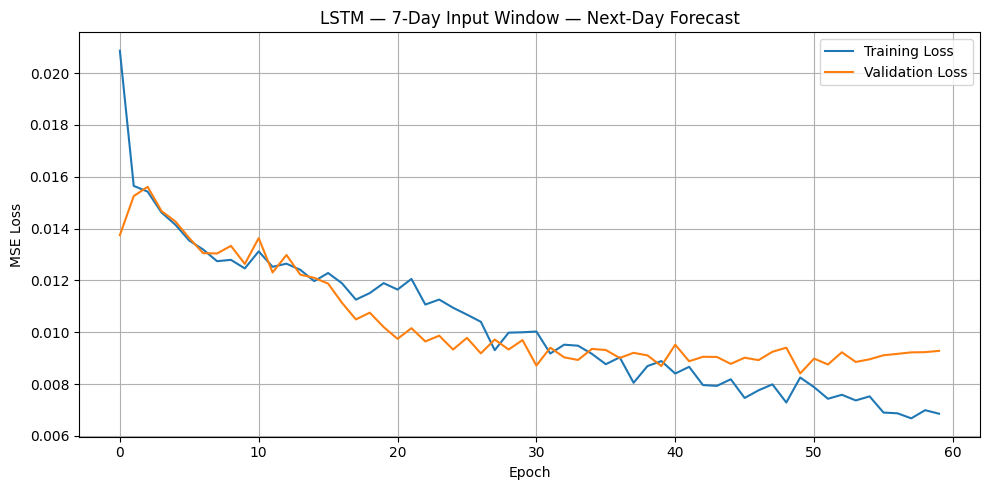

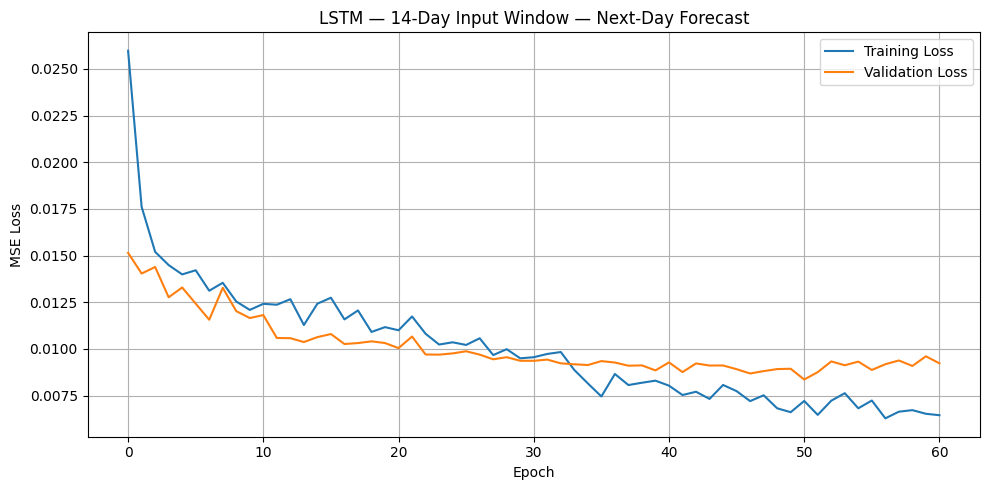

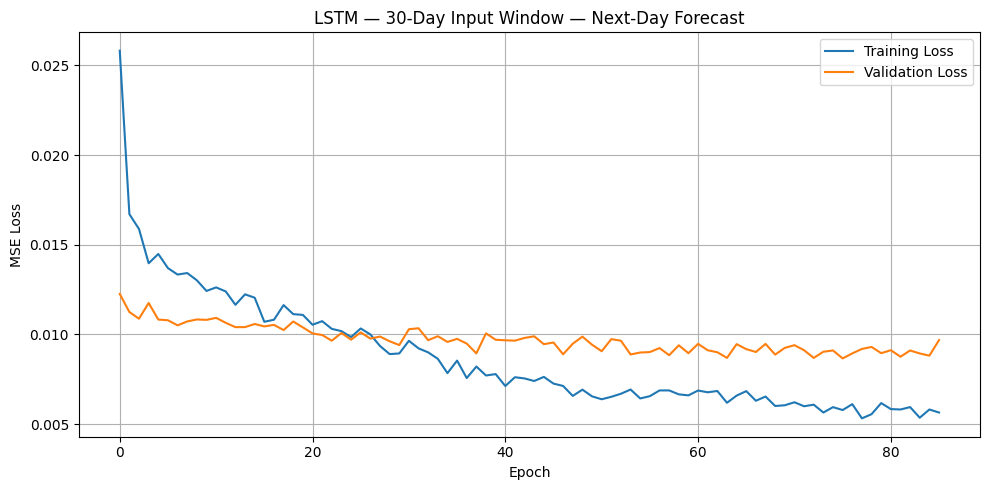

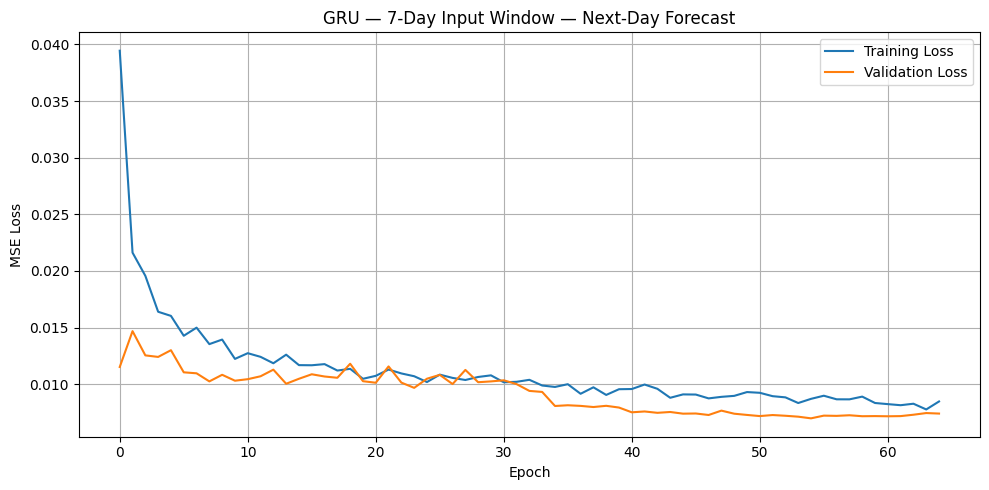

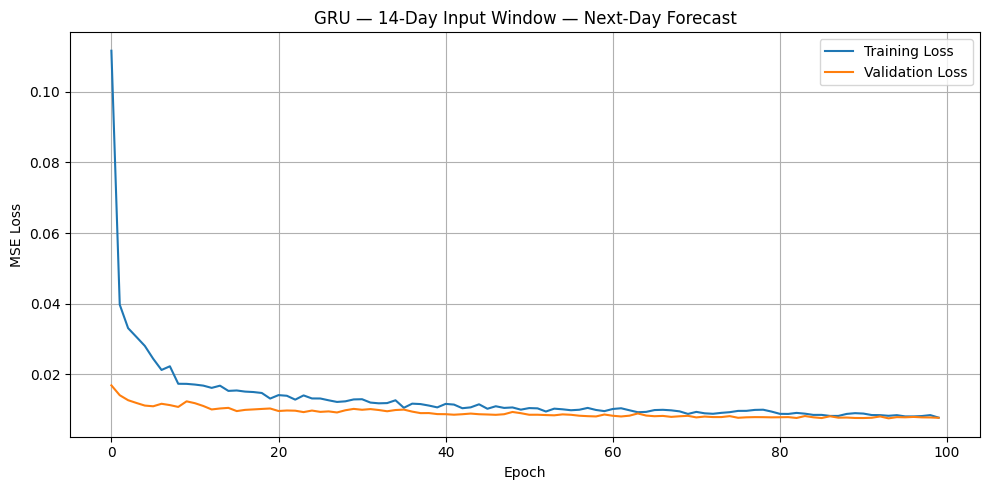

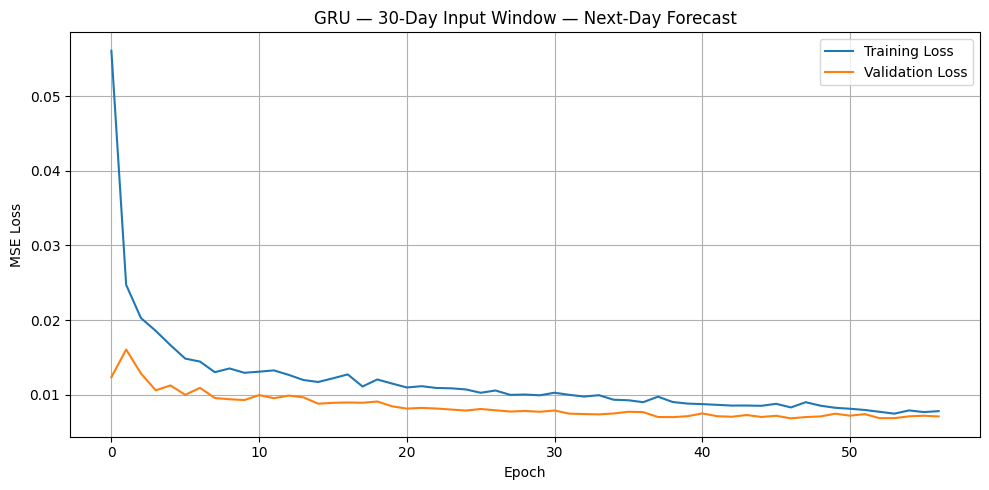

In [14]:
# ============================================================
# 11. BEST TRAINING HISTORIES
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        history = best_histories[
            (model_type, look_back)
        ]

        plt.figure(figsize=(10, 5))
        plt.plot(
            history.history["loss"],
            label="Training Loss"
        )
        plt.plot(
            history.history["val_loss"],
            label="Validation Loss"
        )

        plt.title(
            f"{model_type} — {look_back}-Day Input Window — "
            "Next-Day Forecast"
        )
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

When working with scaled data, it's essential to convert predictions back to their original units for meaningful interpretation. This section emphasizes that all our model evaluations on the test set will be performed on PM2.5 values that have been 'inverse scaled' back to their original measurement units. This makes the error metrics directly comparable to real-world PM2.5 levels, making them easier to understand and relate to other studies or benchmarks.

# 12. Evaluation on the original PM2.5 scale

The models were trained using scaled data, but the final predictions are **inverse-transformed back to the original PM2.5 units before calculating the metrics**.

This is important because scaled metrics are not directly interpretable as PM2.5 error and can be difficult to compare with results reported by other models or studies.

Now that our models are trained and tuned, this section performs the final evaluation on the untouched test set. For each best-performing LSTM and GRU model (across all input window lengths), we generate predictions. Crucially, both the actual PM2.5 values and the model's predictions are inverse-transformed back to their original scale. We then calculate several standard forecasting metrics (like MAE, RMSE, MAPE, R²) and store them in the `metrics_df` DataFrame. This table gives us a comprehensive overview of how each model performed on data it has never seen before.

In [15]:
# ============================================================
# 12. METRICS
# ============================================================

def safe_mape(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    if not np.any(mask):
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )


def calculate_metrics(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MBE": np.mean(y_pred - y_true),
        "MSE": mse,
        "MAPE (%)": safe_mape(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        )
    }

In [33]:
overall_results = []
predictions = {}

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        model = best_models[(model_type, look_back)]

        X_test = datasets[look_back]["test"]["X"]
        y_test_scaled = datasets[look_back]["test"]["y"]

        # Direct model call avoids repeated model.predict() retracing
        y_pred_scaled = model(
            X_test,
            training=False
        ).numpy().ravel()

        # Inverse transform both actual and predicted values
        y_true = target_scaler.inverse_transform(
            y_test_scaled.reshape(-1, 1)
        ).ravel()

        y_pred = target_scaler.inverse_transform(
            y_pred_scaled.reshape(-1, 1)
        ).ravel()

        metrics = calculate_metrics(
            y_true,
            y_pred
        )

        metrics.update({
            "Model": model_type,
            "Input_Window": look_back
        })

        overall_results.append(metrics)

        predictions[(model_type, look_back)] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "indices": datasets[look_back]["test"]["indices"]
        }

metrics_df = pd.DataFrame(overall_results)

metrics_df = metrics_df[
    [
        "Model",
        "Input_Window",
        "MBE",
        "MSE",
        "MAPE (%)",
        "R²",
        "RMSE",
        "MAE"
    ]
]

display(
    metrics_df.sort_values(
        ["Input_Window", "RMSE"]
    )
)

,Model,Input_Window,MBE,MSE,MAPE (%),R²,RMSE,MAE
3,GRU,7,-0.761643,14.905883,34.078611,0.418626,3.860814,2.802511
0,LSTM,7,-0.831053,15.373166,32.079664,0.400401,3.920863,2.698796
1,LSTM,14,-0.407191,14.841144,33.663580,0.421151,3.852421,2.698380
4,GRU,14,-0.523569,15.756102,35.869866,0.385465,3.969396,2.858880
5,GRU,30,-0.852087,15.210176,34.025611,0.406758,3.900023,2.783163
2,LSTM,30,-0.644663,16.298792,36.405093,0.364299,4.037176,2.911015


This section provides a brief explanation of what the evaluation results mean. It clarifies that this experiment specifically compares how varying the *length of historical data provided to the model* (the input window of 7, 14, or 30 days) affects the accuracy of predicting **the very next day's PM2.5 value**. It's important to remember that this is *not* about forecasting 7, 14, or 30 days into the future, but rather examining the impact of historical context on a fixed, short-term prediction task.

# 14. What the corrected comparison tells us

This table compares **the same next-day forecasting task** while changing only the historical input window.

Therefore:
- a 7-day input window means the model sees the previous 7 days;
- a 14-day input window means it sees the previous 14 days;
- a 30-day input window means it sees the previous 30 days.

This makes the comparison useful for investigating whether additional historical context improves next-day PM2.5 prediction.

These plots visually represent the performance metrics calculated in the previous step. For each metric (MAE, RMSE, MAPE, etc.), we plot how LSTM and GRU models performed with different historical input window lengths (7, 14, and 30 days). These line plots help us quickly identify trends: for example, whether increasing the input window generally improves or worsens performance for a given model, and which model type (LSTM or GRU) tends to perform better across different scenarios.

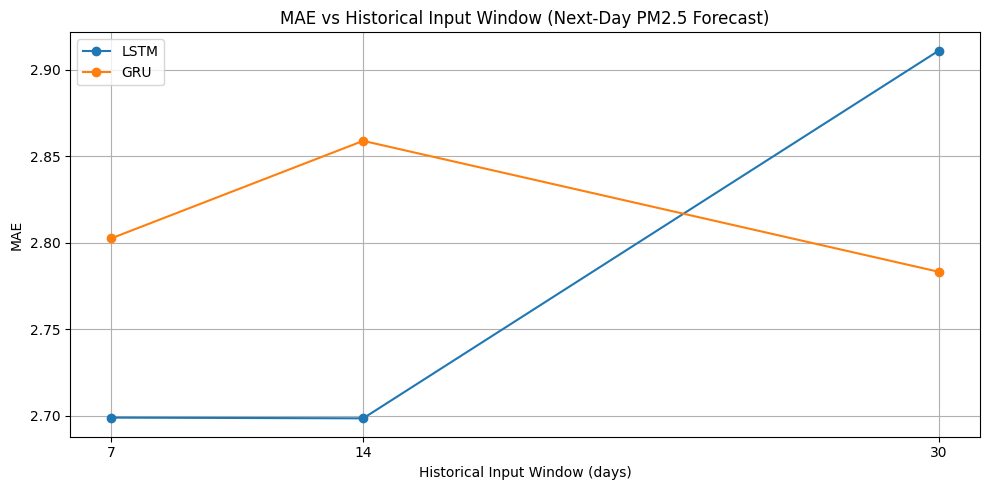

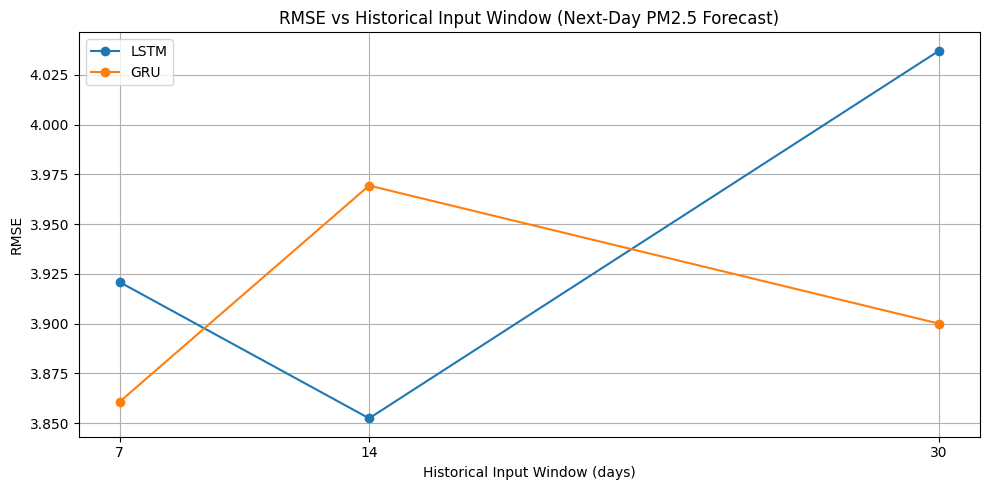

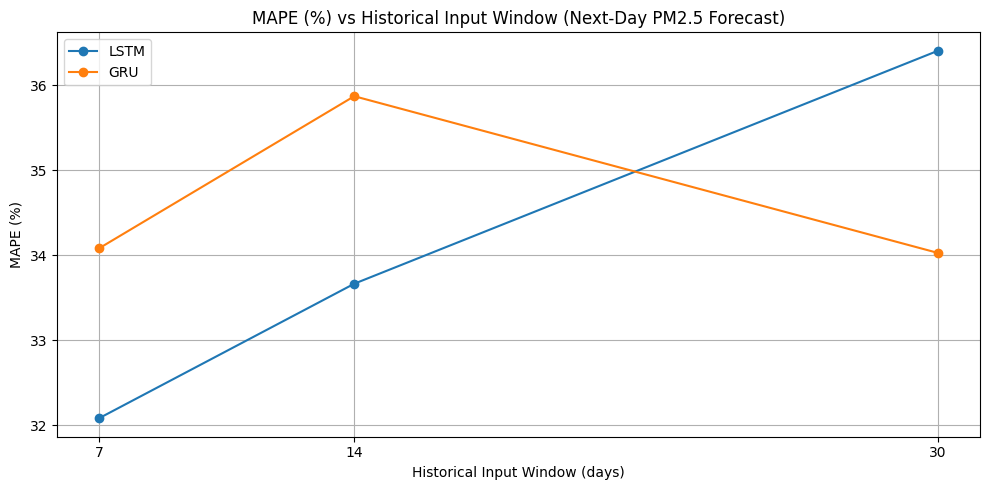

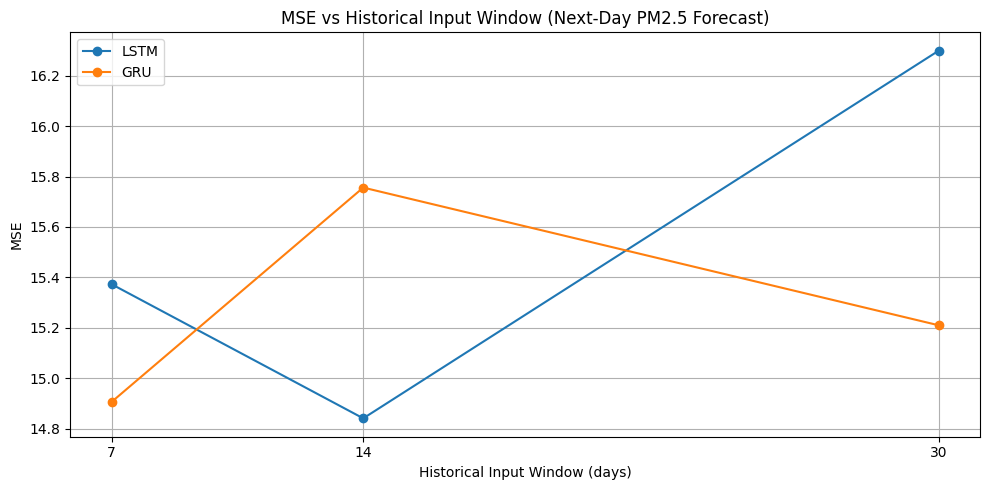

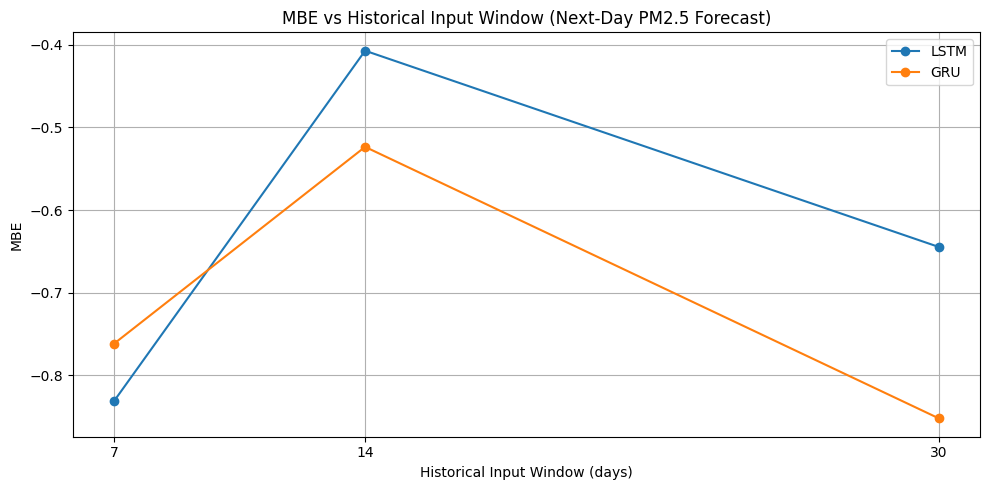

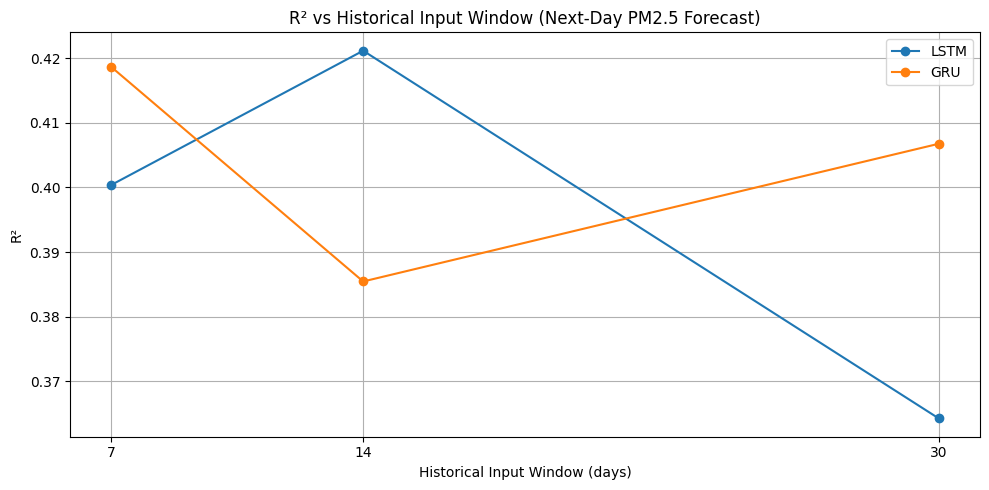

In [17]:
# ============================================================
# 15. METRIC COMPARISON PLOTS
# ============================================================

for metric in ["MAE", "RMSE", "MAPE (%)", "MSE", "MBE", "R²"]:

    plt.figure(figsize=(10, 5))

    for model_type in ["LSTM", "GRU"]:

        subset = metrics_df[
            metrics_df["Model"] == model_type
        ].sort_values("Input_Window")

        plt.plot(
            subset["Input_Window"],
            subset[metric],
            marker="o",
            label=model_type
        )

    plt.xlabel("Historical Input Window (days)")
    plt.ylabel(metric)
    plt.title(
        f"{metric} vs Historical Input Window "
        "(Next-Day PM2.5 Forecast)"
    )
    plt.xticks(LOOK_BACKS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

These plots show a direct comparison between the *actual* PM2.5 values from the test set and the *predicted* PM2.5 values from our best LSTM and GRU models for each input window. By plotting them on the same graph, we can visually assess how closely the model's forecasts track the real-world fluctuations. Ideally, the predicted line should closely follow the actual line, indicating good forecasting accuracy. Deviations highlight periods where the model struggled.

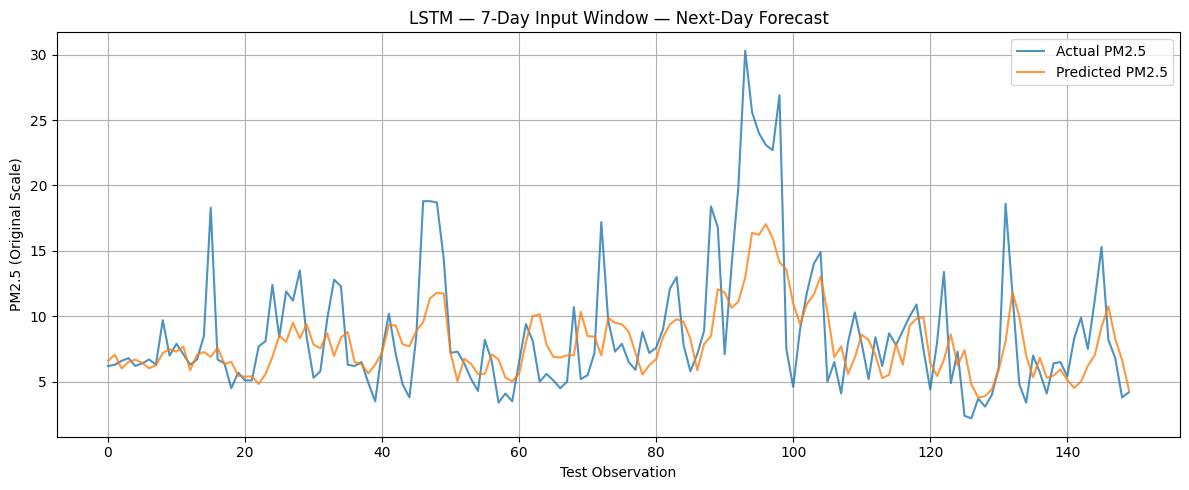

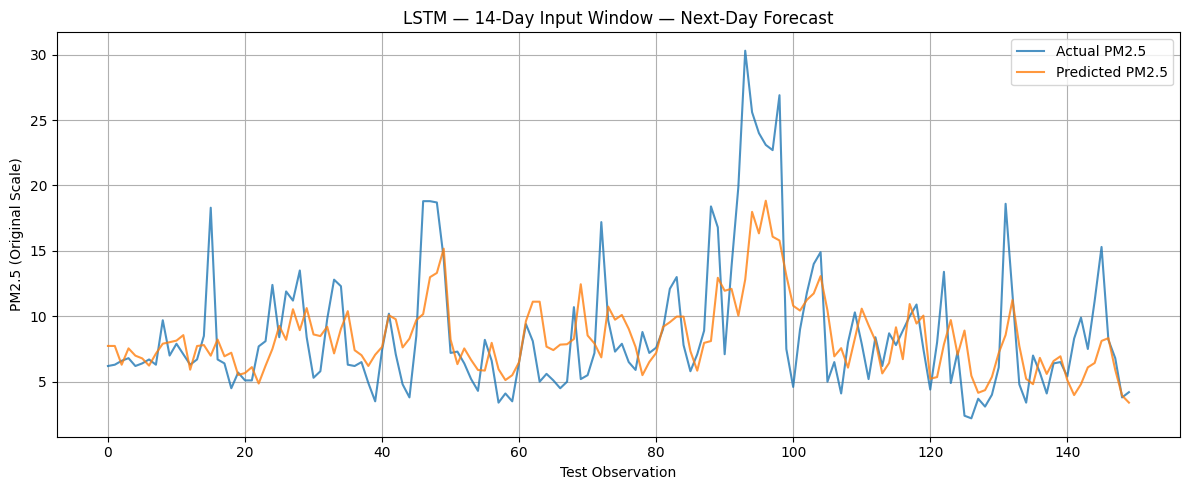

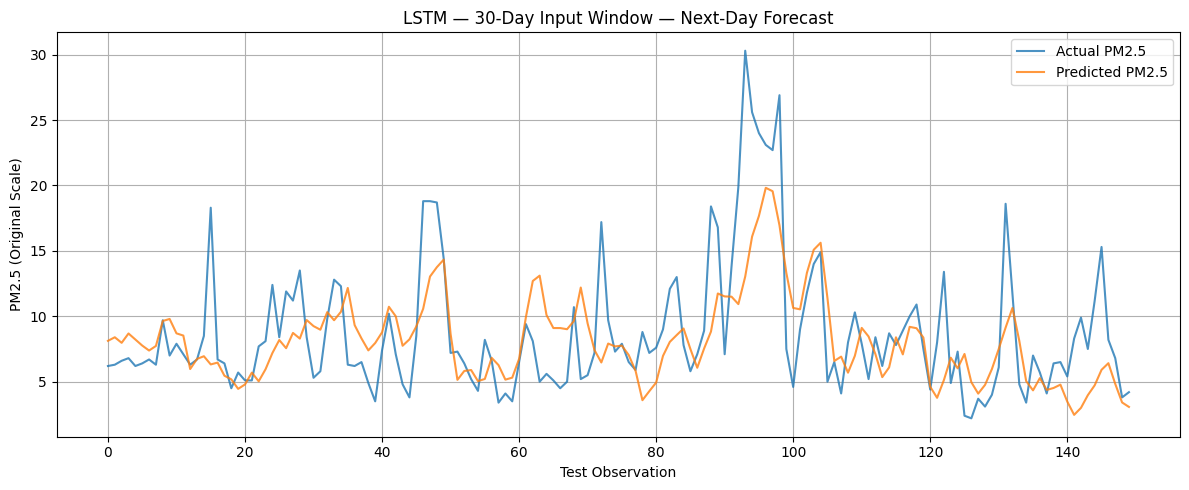

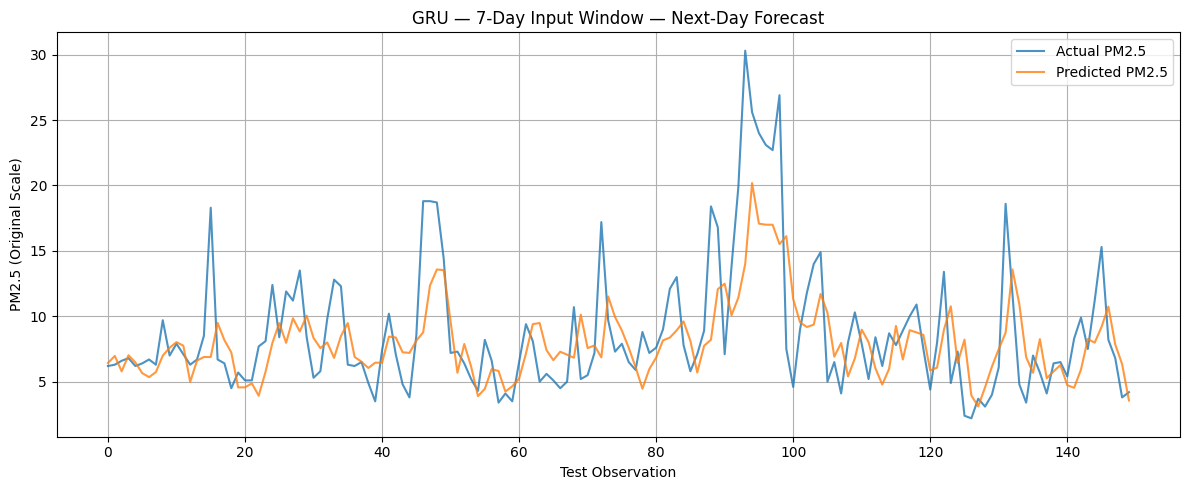

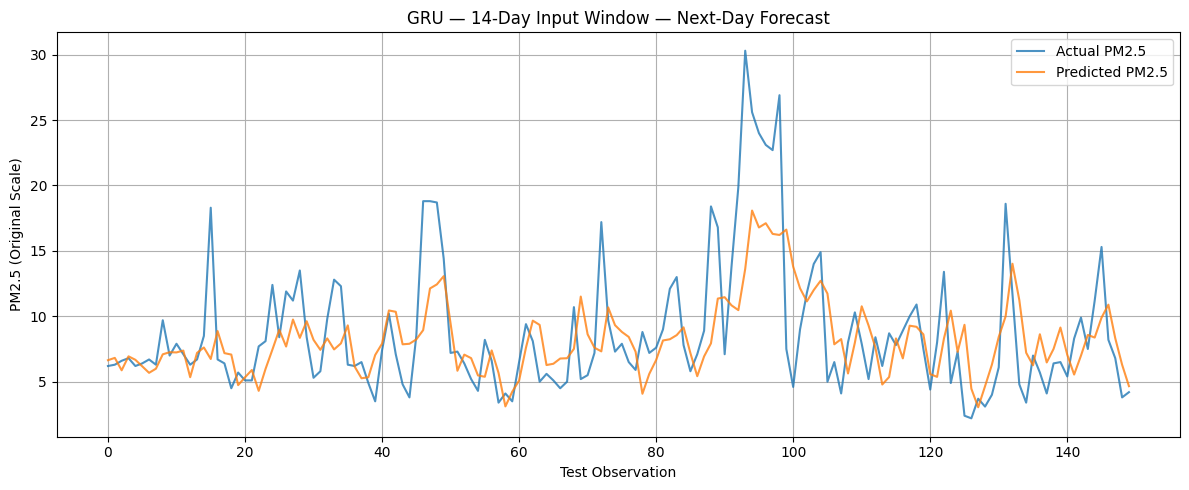

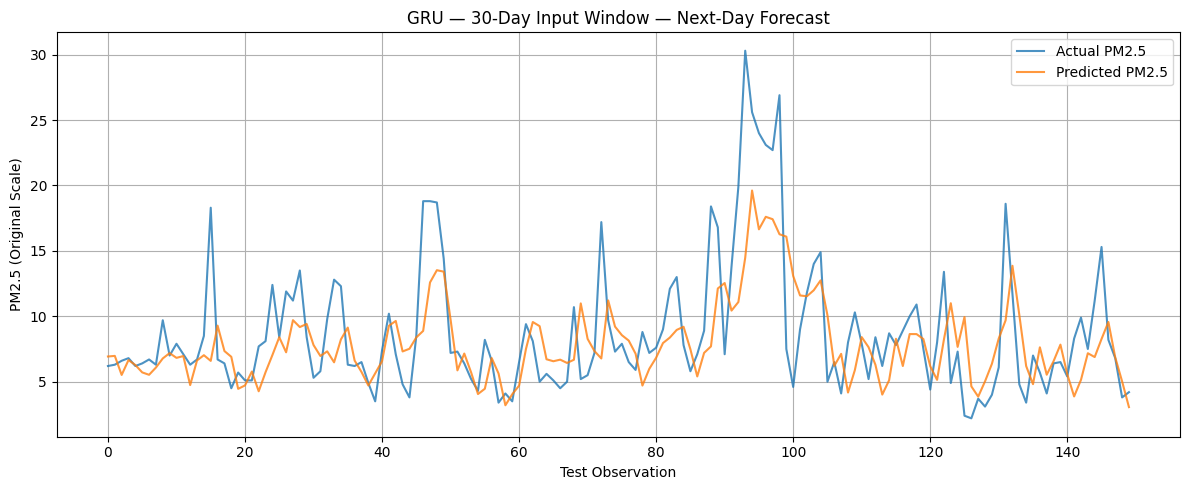

In [18]:
# ============================================================
# 16. ACTUAL VS PREDICTED — ORIGINAL PM2.5 SCALE
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        result = predictions[
            (model_type, look_back)
        ]

        plt.figure(figsize=(12, 5))

        plt.plot(
            result["y_true"],
            label="Actual PM2.5",
            alpha=0.8
        )

        plt.plot(
            result["y_pred"],
            label="Predicted PM2.5",
            alpha=0.8
        )

        plt.title(
            f"{model_type} — {look_back}-Day Input Window — "
            "Next-Day Forecast"
        )

        plt.xlabel("Test Observation")
        plt.ylabel("PM2.5 (Original Scale)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

These scatter plots provide another way to visualize the relationship between actual and predicted PM2.5 values. Each point represents a single observation from the test set, with its actual value on the x-axis and its predicted value on the y-axis. The dashed line represents a 'perfect prediction' where actual equals predicted. Points clustered tightly around this dashed line indicate high accuracy, while scattered points far from the line suggest larger errors. These plots help us see the overall spread and bias of the predictions.

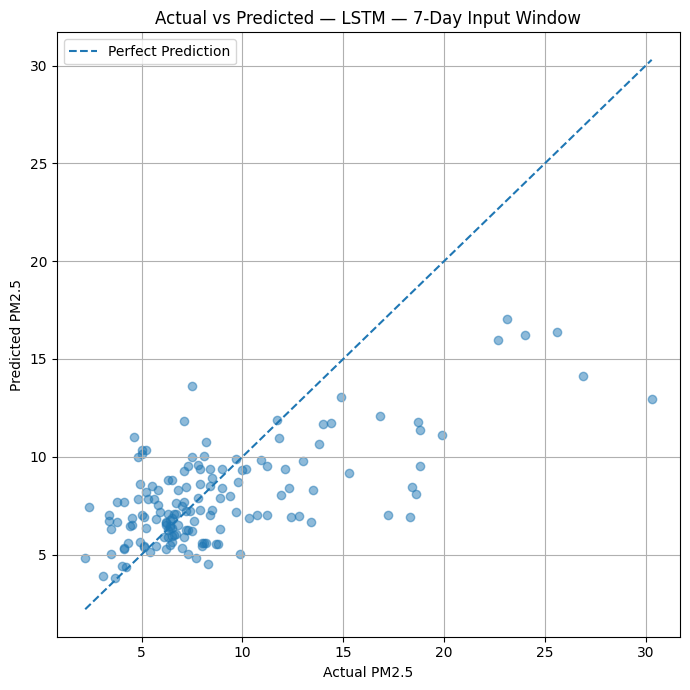

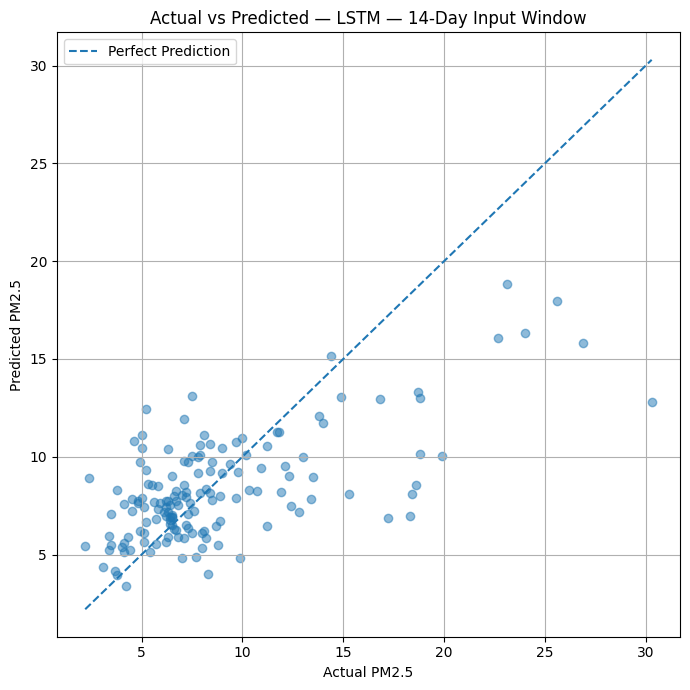

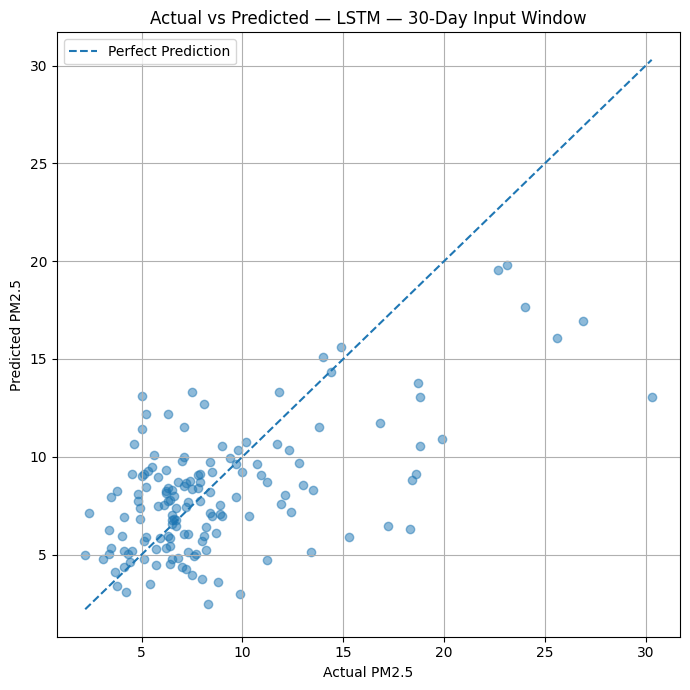

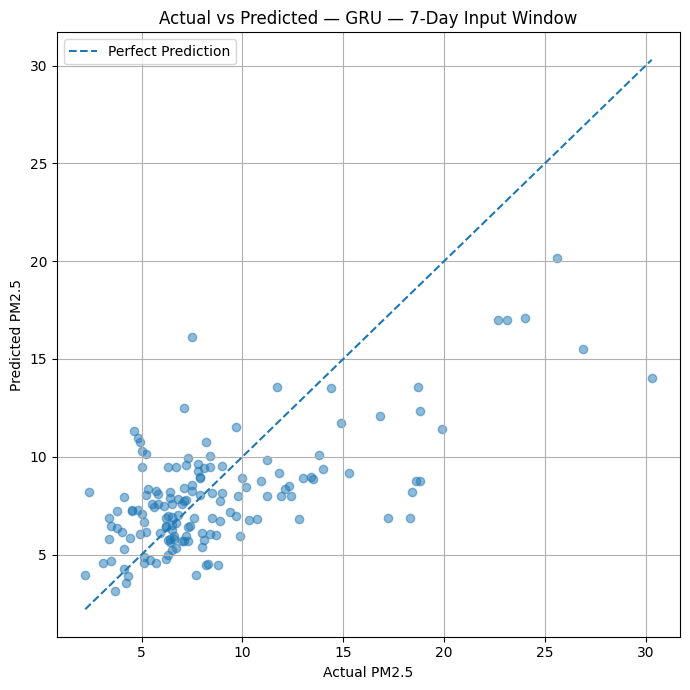

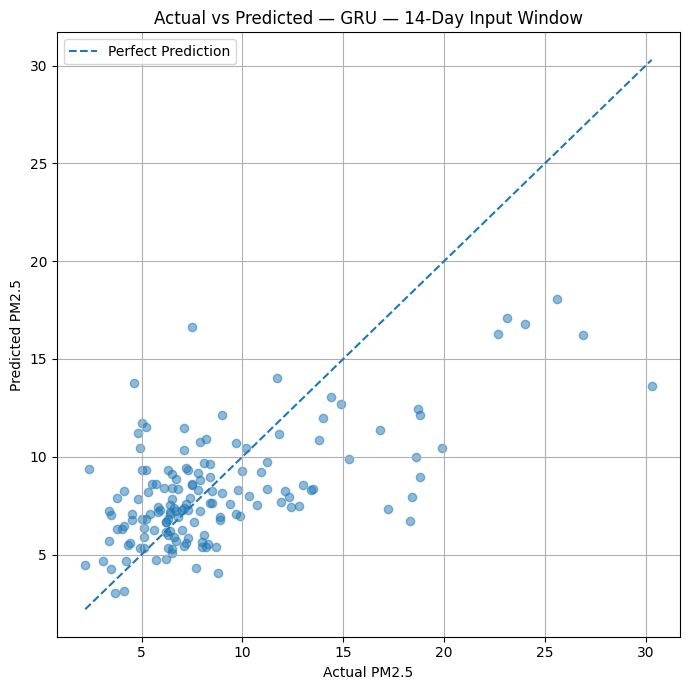

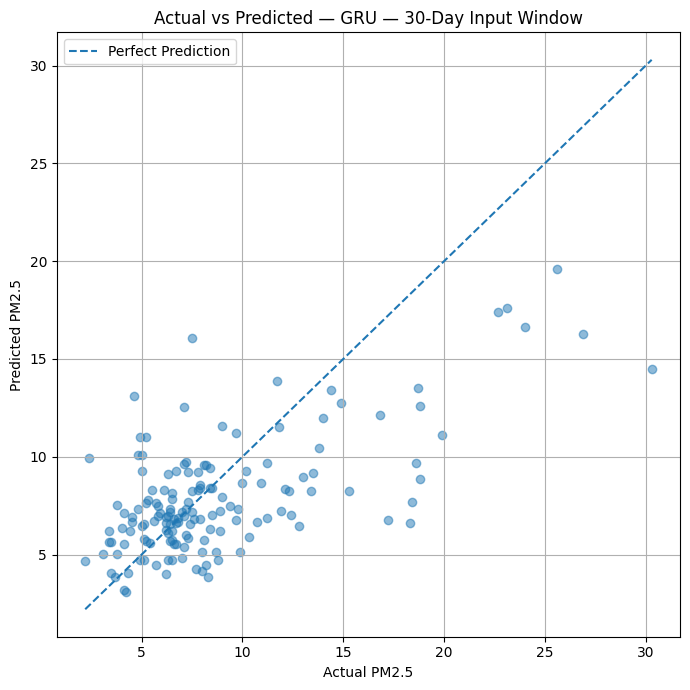

In [19]:
# ============================================================
# 17. SCATTER: ACTUAL VS PREDICTED
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        result = predictions[
            (model_type, look_back)
        ]

        y_true = result["y_true"]
        y_pred = result["y_pred"]

        plt.figure(figsize=(7, 7))

        plt.scatter(
            y_true,
            y_pred,
            alpha=0.5
        )

        lower = min(
            y_true.min(),
            y_pred.min()
        )

        upper = max(
            y_true.max(),
            y_pred.max()
        )

        plt.plot(
            [lower, upper],
            [lower, upper],
            linestyle="--",
            label="Perfect Prediction"
        )

        plt.xlabel("Actual PM2.5")
        plt.ylabel("Predicted PM2.5")
        plt.title(
            f"Actual vs Predicted — {model_type} — "
            f"{look_back}-Day Input Window"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

Residuals, or forecast errors, are simply the difference between the actual PM2.5 values and the predicted PM2.5 values. This section plots these residuals over time for each model and input window. Ideally, residuals should be randomly scattered around zero, with no discernible patterns (like trends or seasonality). A horizontal dashed line at zero helps visualize this. Patterns in residuals can indicate that the model is missing some underlying information or structure in the data.

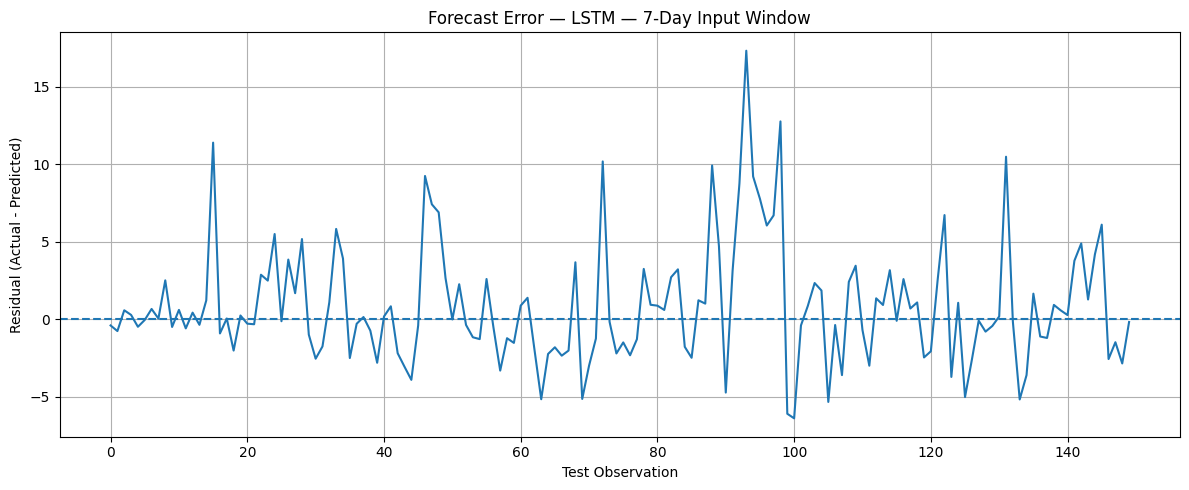

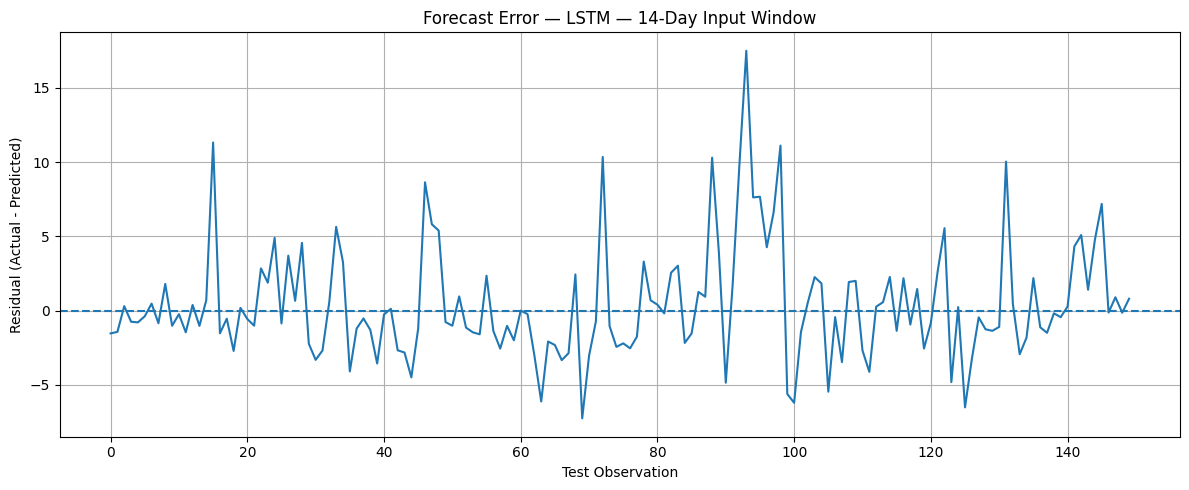

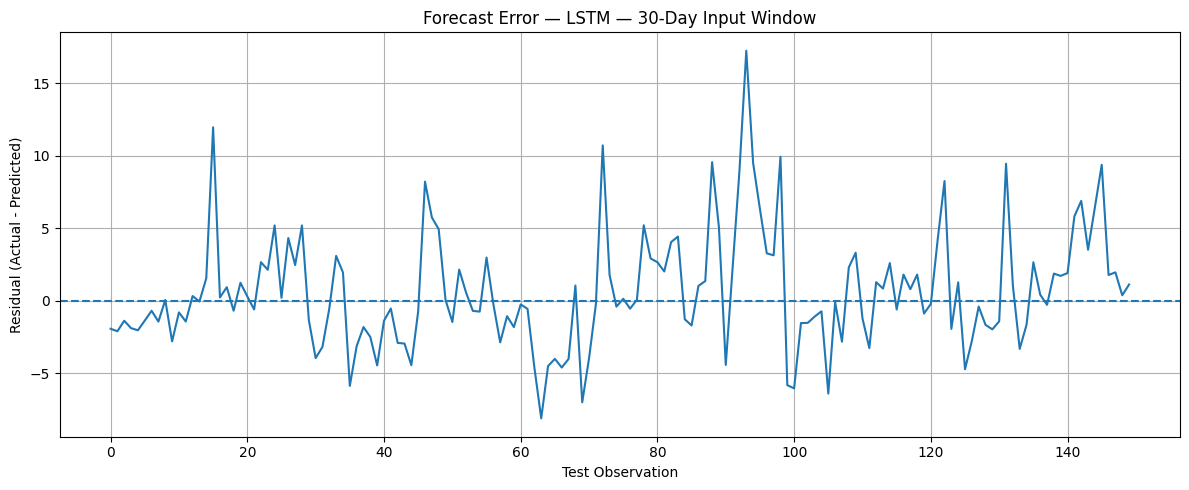

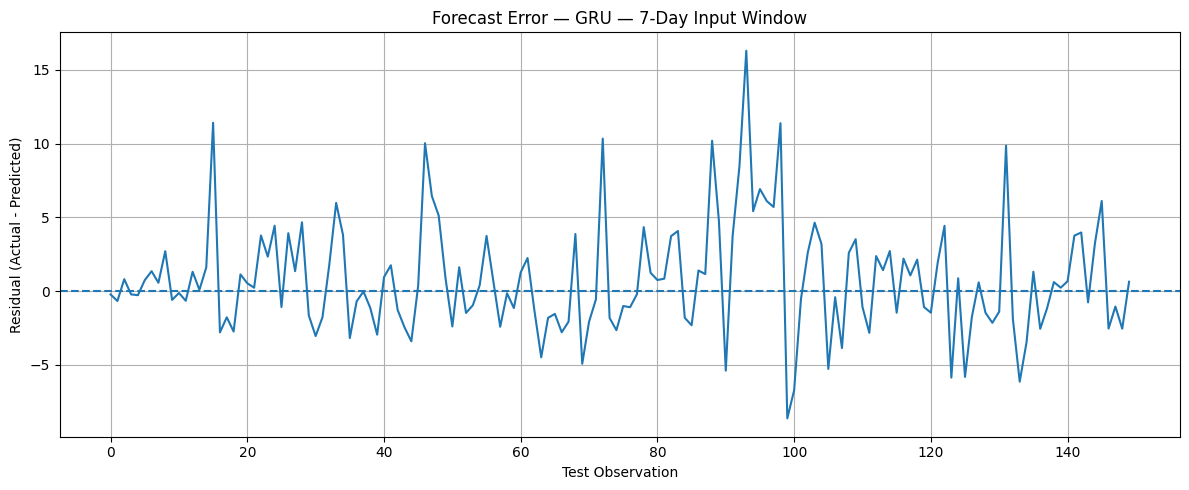

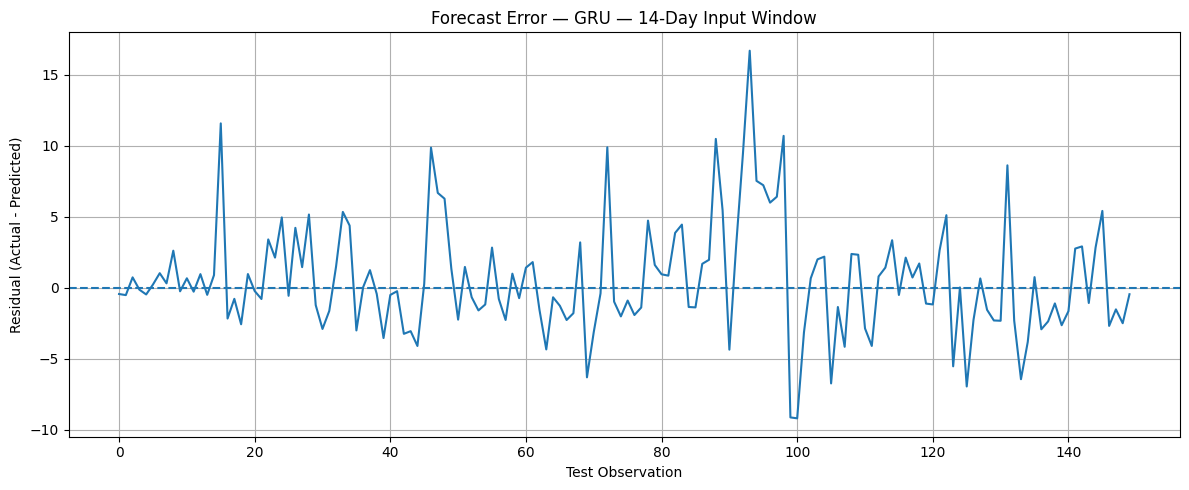

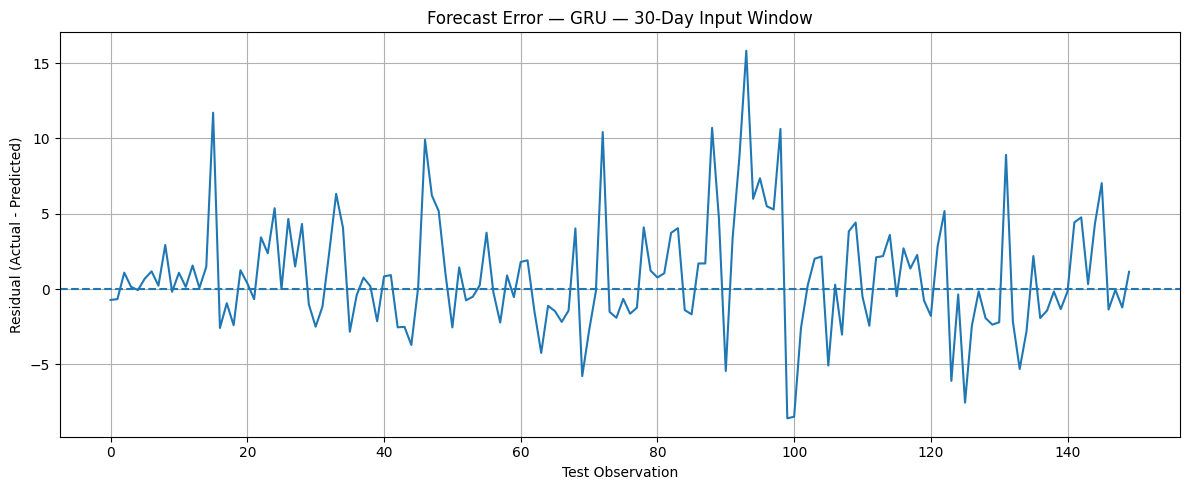

In [20]:
# ============================================================
# 18. RESIDUALS / FORECAST ERROR
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        result = predictions[
            (model_type, look_back)
        ]

        residuals = (
            result["y_true"] -
            result["y_pred"]
        )

        plt.figure(figsize=(12, 5))

        plt.plot(
            residuals
        )

        plt.axhline(
            0,
            linestyle="--"
        )

        plt.xlabel("Test Observation")
        plt.ylabel("Residual (Actual - Predicted)")
        plt.title(
            f"Forecast Error — {model_type} — "
            f"{look_back}-Day Input Window"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

These histograms visualize the distribution of the forecast errors (residuals). A good model should ideally have errors that are normally distributed around zero. A narrow, symmetric distribution centered at zero suggests that the model's predictions are generally unbiased and accurate. Skewed or widely spread distributions can point to issues like consistent over- or under-prediction, or a large number of significant errors.

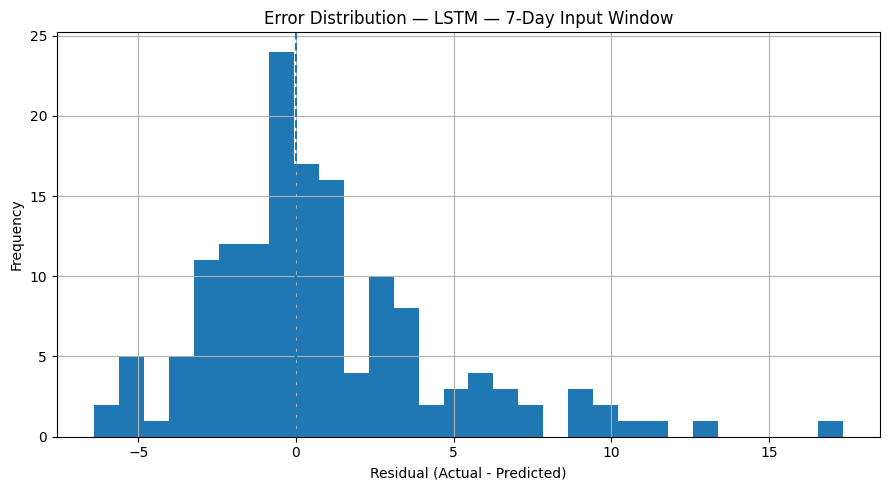

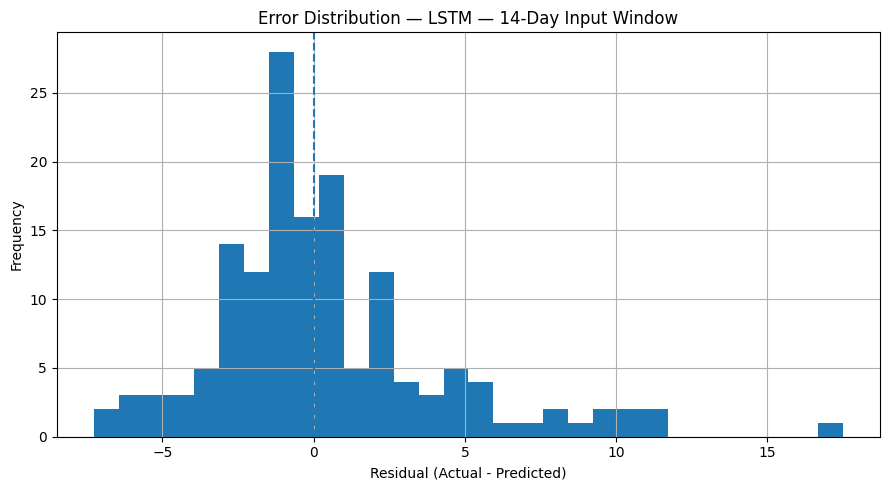

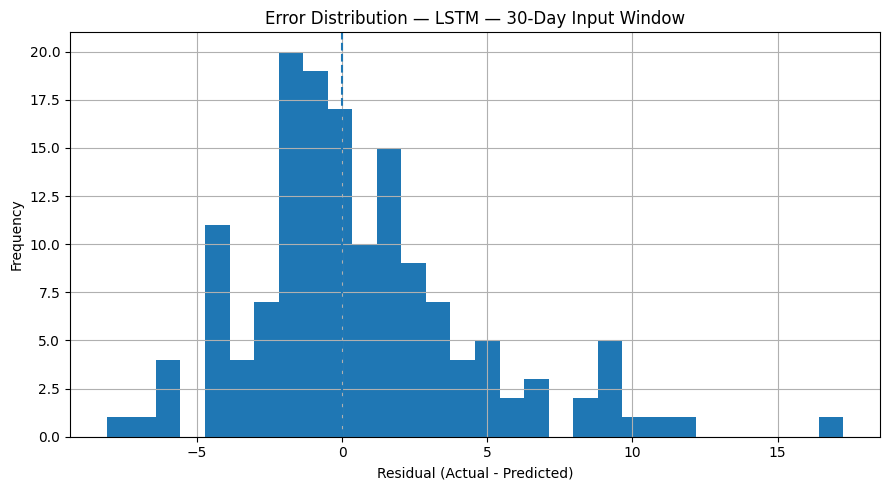

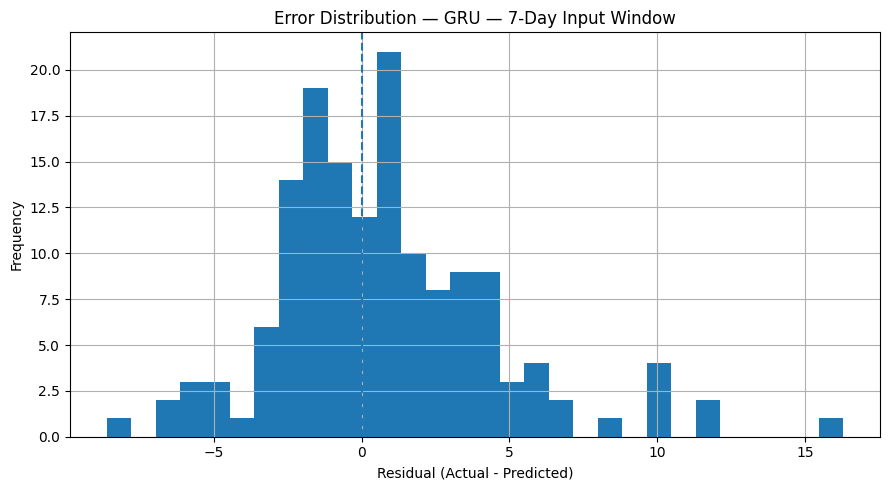

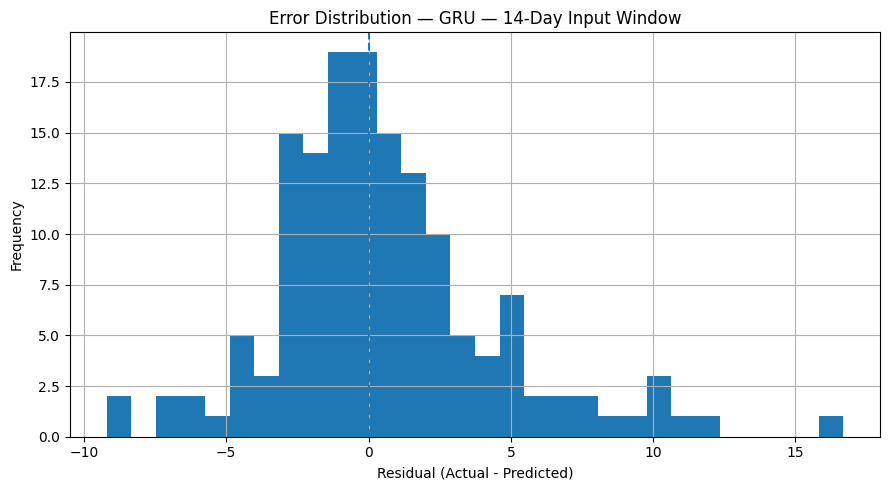

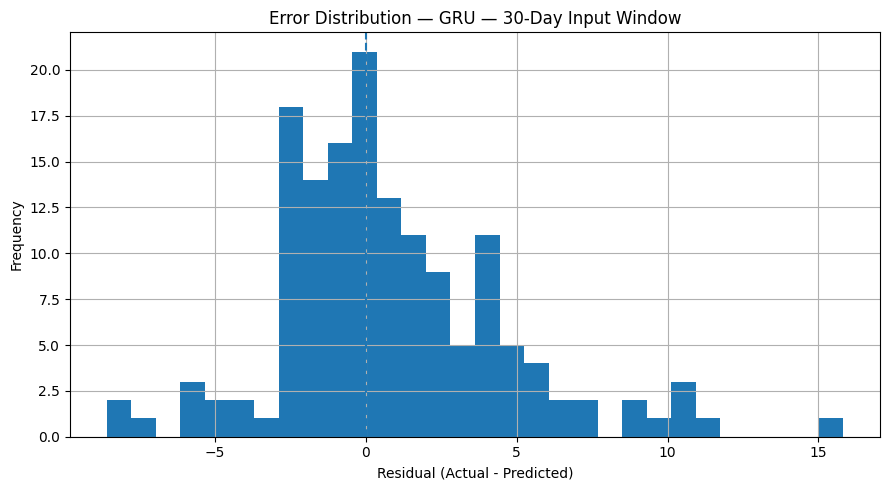

In [21]:
# ============================================================
# 19. ERROR DISTRIBUTIONS
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for look_back in LOOK_BACKS:

        result = predictions[
            (model_type, look_back)
        ]

        errors = (
            result["y_true"] -
            result["y_pred"]
        )

        plt.figure(figsize=(9, 5))

        plt.hist(
            errors,
            bins=30
        )

        plt.axvline(
            0,
            linestyle="--"
        )

        plt.xlabel("Residual (Actual - Predicted)")
        plt.ylabel("Frequency")
        plt.title(
            f"Error Distribution — {model_type} — "
            f"{look_back}-Day Input Window"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

This section summarizes the key finding regarding the historical input window. It highlights which input window length (7, 14, or 30 days) resulted in the best next-day prediction performance for each model (LSTM and GRU) based on the calculated RMSE metric. This directly addresses the main question of the experiment: whether more historical data always leads to better short-term forecasts, or if there's an optimal amount of context for these specific models.

# 20. Direct comparison of input-window performance

The most important result for this experiment is whether increasing the historical input window from 7 to 14 to 30 days produces better or worse **next-day** predictions.

A deterioration in performance as the input window increases would suggest that providing additional historical observations does not necessarily improve next-day prediction and may introduce older, less relevant patterns or additional noise.

In [22]:
# ============================================================
# 20. BEST INPUT WINDOW FOR EACH MODEL
# ============================================================

best_window_by_model = (
    metrics_df
    .sort_values("RMSE")
    .groupby("Model", as_index=False)
    .first()
)

display(best_window_by_model)

,Model,Input_Window,MBE,MSE,MAPE (%),R²,RMSE,MAE
0,GRU,7,-0.761643,14.905883,34.078611,0.418626,3.860814,2.802511
1,LSTM,14,-0.407191,14.841144,33.663581,0.421151,3.852421,2.698380


Finally, we save all the important results from our experiment. This includes the performance metrics for all models (`metrics_df`), the detailed hyperparameter tuning logs (`tuning_df`), and the best hyperparameters found (`best_tuning_df`). Crucially, we also save the actual and predicted PM2.5 values along with the residuals for each model and input window. This ensures that all our findings are preserved and can be easily accessed or shared for further analysis or reporting.

In [23]:
# ============================================================
# 21. SAVE RESULTS
# ============================================================

OUTPUT_DIR = "next_day_input_window_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "next_day_metrics_original_scale.csv"
    ),
    index=False
)

tuning_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "hyperparameter_tuning_results.csv"
    ),
    index=False
)

best_tuning_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_hyperparameters.csv"
    ),
    index=False
)

for (model_type, look_back), result in predictions.items():

    out = pd.DataFrame({
        "Date": df.loc[
            result["indices"],
            "date"
        ].values,
        "Actual_PM25": result["y_true"],
        "Predicted_PM25": result["y_pred"],
        "Residual": (
            result["y_true"] -
            result["y_pred"]
        )
    })

    filename = (
        f"{model_type.lower()}_"
        f"{look_back}day_input_window_next_day.csv"
    )

    out.to_csv(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        index=False
    )

print("Results saved to:", OUTPUT_DIR)

Results saved to: next_day_input_window_results


This section identifies the single best-performing model across *all* experiments, considering both model type (LSTM/GRU) and historical input window length (7, 14, 30 days), based on the lowest Root Mean Squared Error (RMSE). It then visualizes the `Actual vs Predicted` and `Forecast Error` plots specifically for this top-performing model, providing a focused view of our best result.

## 22. Overall Best Model Evaluation

,1
Model,LSTM
Input_Window,14
MBE,-0.407191
MSE,14.841144
MAPE (%),33.663581
R²,0.421151
RMSE,3.852421
MAE,2.69838



Overall Best Model: LSTM with 14-day Input Window


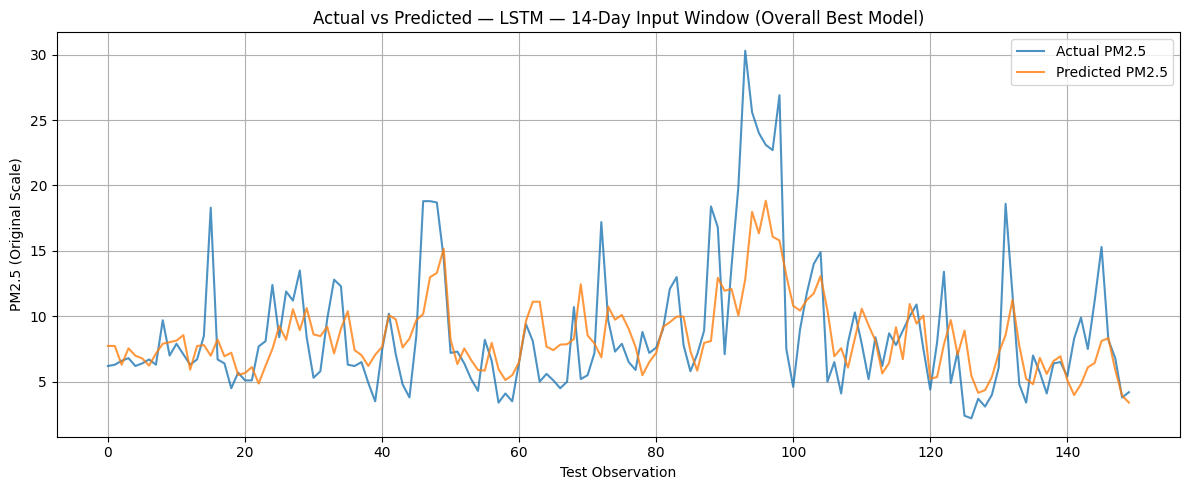

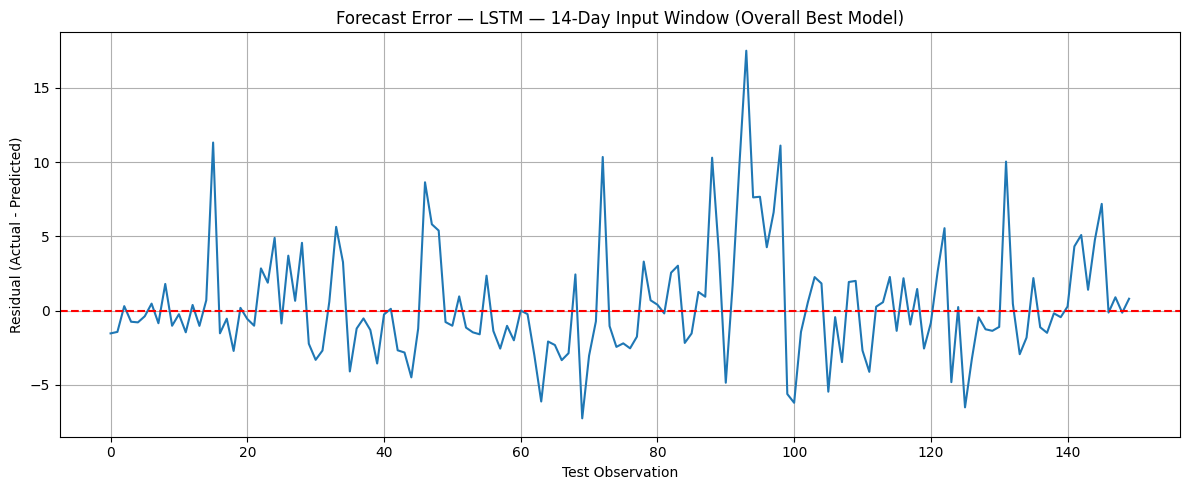

In [24]:
overall_best_model_metrics = metrics_df.sort_values('RMSE').iloc[0]
display(overall_best_model_metrics)

model_type = overall_best_model_metrics['Model']
look_back = overall_best_model_metrics['Input_Window']

print(f"\nOverall Best Model: {model_type} with {look_back}-day Input Window")

# Retrieve predictions for the overall best model
best_model_predictions = predictions[(model_type, look_back)]

y_true_best = best_model_predictions['y_true']
y_pred_best = best_model_predictions['y_pred']

# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_true_best, label='Actual PM2.5', alpha=0.8)
plt.plot(y_pred_best, label='Predicted PM2.5', alpha=0.8)
plt.title(f'Actual vs Predicted — {model_type} — {look_back}-Day Input Window (Overall Best Model)')
plt.xlabel('Test Observation')
plt.ylabel('PM2.5 (Original Scale)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Residuals
residuals_best = y_true_best - y_pred_best
plt.figure(figsize=(12, 5))
plt.plot(residuals_best)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Test Observation')
plt.ylabel('Residual (Actual - Predicted)')
plt.title(f'Forecast Error — {model_type} — {look_back}-Day Input Window (Overall Best Model)')
plt.grid(True)
plt.tight_layout()
plt.show()

This section concludes the methodology discussion by explicitly stating the correct way to describe the experiment's objective. It re-emphasizes that the goal was to investigate the impact of varying historical input window lengths (7, 14, and 30 days) on a *fixed next-day PM2.5 prediction task*, not to perform multi-day-ahead forecasting. This clarifies the experimental design and its implications for interpreting the results.

# 22. Methodology conclusion

This corrected experiment should be described as:

> **Next-day PM2.5 forecasting using 7-, 14- and 30-day historical input windows.**

It should **not** be described as 7-, 14- and 30-day future forecasting.

The separate multi-step notebook can still be used for the actual 7-, 14- and 30-day future forecasting experiment.

This notebook provides a complementary experiment showing how changing the amount of historical information affects a fixed next-day prediction task. Because all final metrics are calculated after inverse scaling, the results are reported in the original PM2.5 units and are suitable for comparison with other model results.

This section provides a concise overview of the best hyperparameters found for each LSTM and GRU model across the different input window lengths. It directly displays the `best_tuning_df` DataFrame, which summarizes the optimal `Units`, `Dropout`, `Batch_Size`, and `Learning_Rate` that yielded the lowest validation loss for each specific model configuration. This table is useful for understanding the fine-tuned settings of our top models.

## 23. Best Hyperparameters Summary

In [25]:
display(best_tuning_df)

,Model,Input_Window,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Validation_Loss
0,LSTM,7,32,0.1,32,0.001,60,0.008411
1,LSTM,14,64,0.2,16,0.001,61,0.008363
2,LSTM,30,64,0.2,32,0.001,86,0.008664
3,GRU,7,32,0.1,32,0.001,65,0.006994
4,GRU,14,32,0.2,32,0.001,100,0.007567
5,GRU,30,32,0.1,16,0.001,57,0.006856


These bar charts offer another visual comparison of the performance metrics across different historical input window lengths for both LSTM and GRU models. Unlike the line plots which show trends, bar charts are effective for direct comparisons of values. Each bar represents a metric value (e.g., MAE, RMSE) for a specific model and input window, making it easy to see which configuration achieved the best result for each metric.

## 25. Metrics vs Historical Input Window (Bar Charts)

As previously discussed, this experiment focuses on next-day PM2.5 prediction while varying the *historical input window* length (7, 14, or 30 days), not the forecast horizon itself. The forecast horizon remains fixed at one day ahead.

Below are bar charts visualizing the performance metrics (MAE, RMSE, MAPE (%), MSE, MBE, R²) across the different historical input window lengths for both LSTM and GRU models.

These plots delve deeper into the hyperparameter tuning process. For each model type (LSTM and GRU) and each input window, they show how the 'Best Validation Loss' (our measure of model performance during tuning) changes as individual hyperparameters (Units, Dropout, Batch Size, Learning Rate) are varied. These visualizations help us understand the tuning landscape and confirm that the chosen best parameters indeed correspond to local (or global) minima in validation loss within our search space.

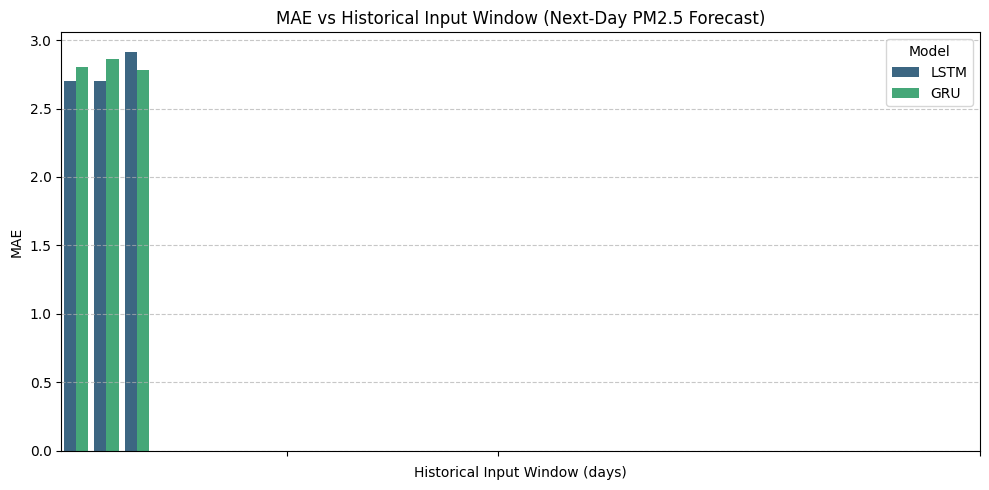

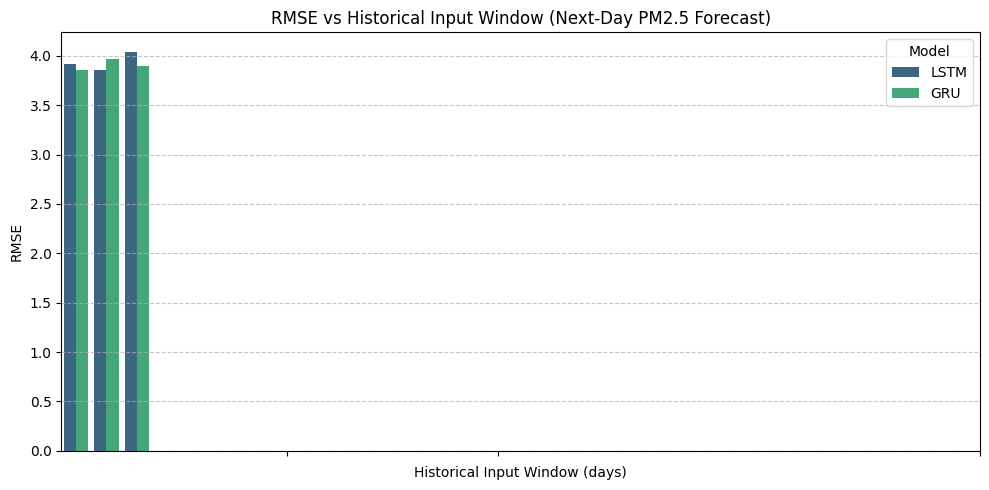

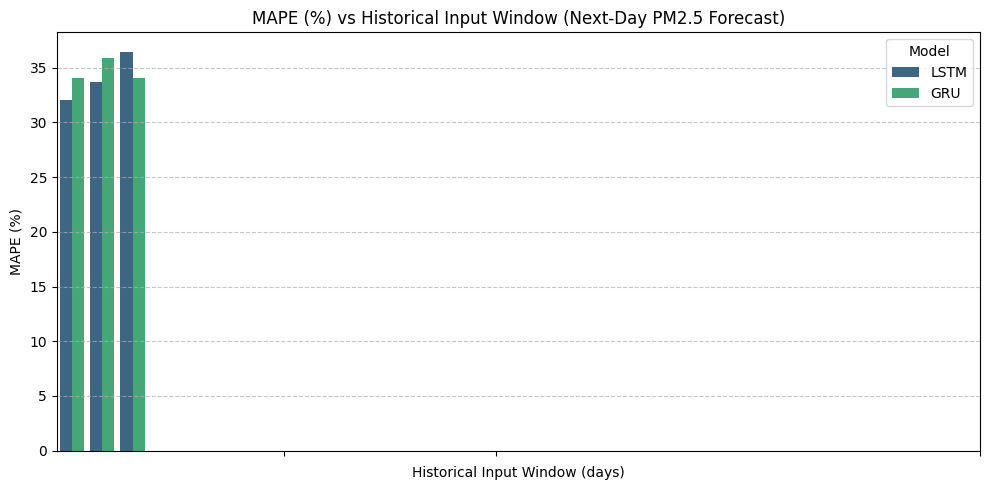

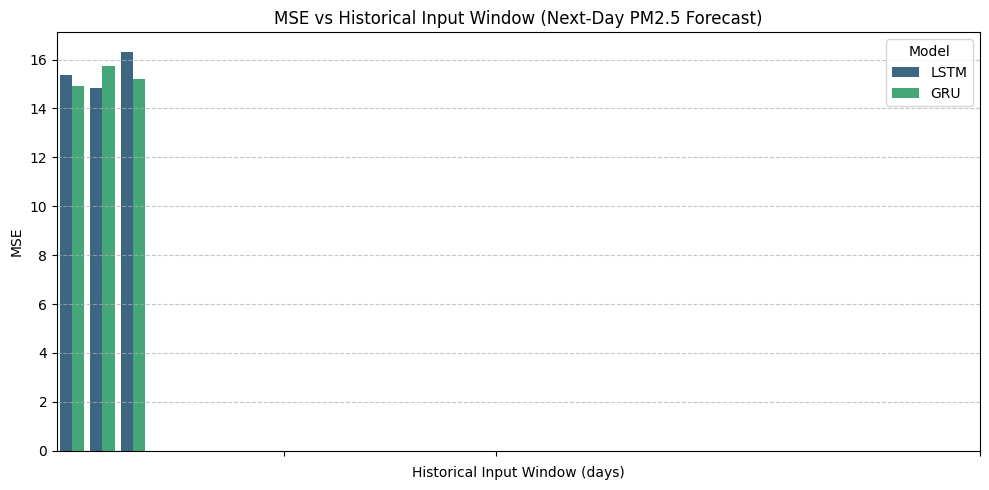

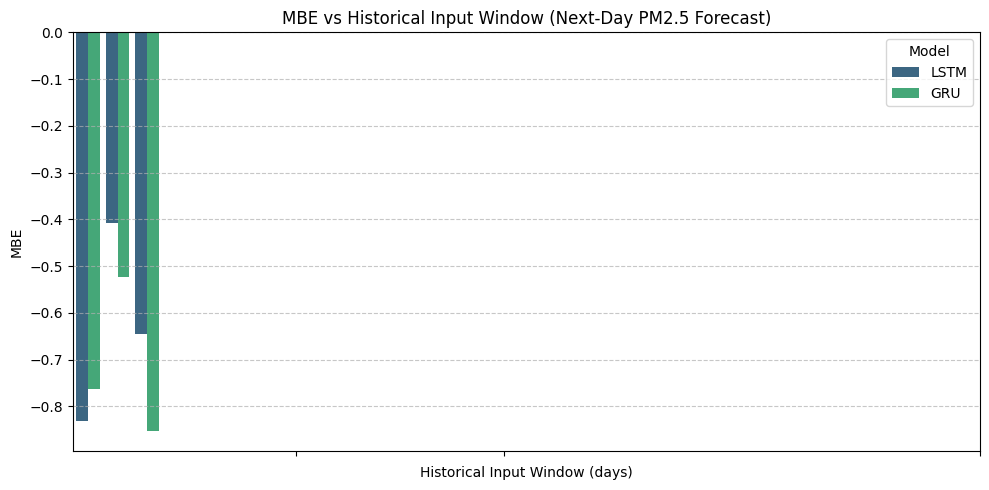

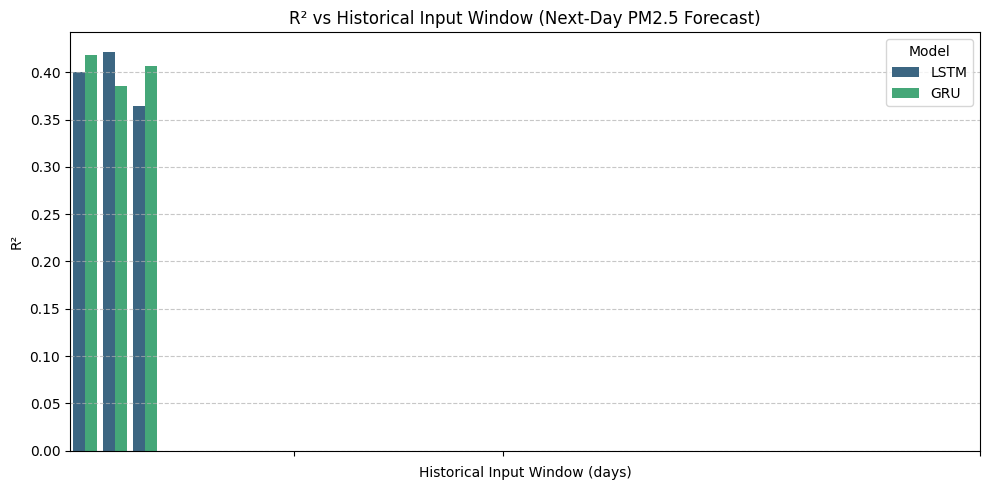

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in ["MAE", "RMSE", "MAPE (%)", "MSE", "MBE", "R²"]:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x="Input_Window",
        y=metric,
        hue="Model",
        data=metrics_df,
        palette="viridis"
    )
    plt.xlabel("Historical Input Window (days)")
    plt.ylabel(metric)
    plt.title(
        f"{metric} vs Historical Input Window (Next-Day PM2.5 Forecast)"
    )
    plt.xticks(LOOK_BACKS)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

## 26. Hyperparameter Tuning Plots

These plots visualize the `Best_Validation_Loss` across the different hyperparameter combinations for each model (LSTM and GRU) and each input window (7, 14, and 30 days). This helps in understanding the tuning landscape and confirming the selection of the best parameters.

A correlation heatmap is a powerful visual tool to understand the relationships between all the numerical features in our dataset, including our target variable 'pm25'. Each colored square indicates the correlation coefficient between two variables: warm colors (e.g., red) suggest a strong positive correlation, cool colors (e.g., blue) suggest a strong negative correlation, and lighter colors indicate weaker correlations. This helps us identify which features might be strong predictors or if there are highly correlated features that could cause multicollinearity issues.

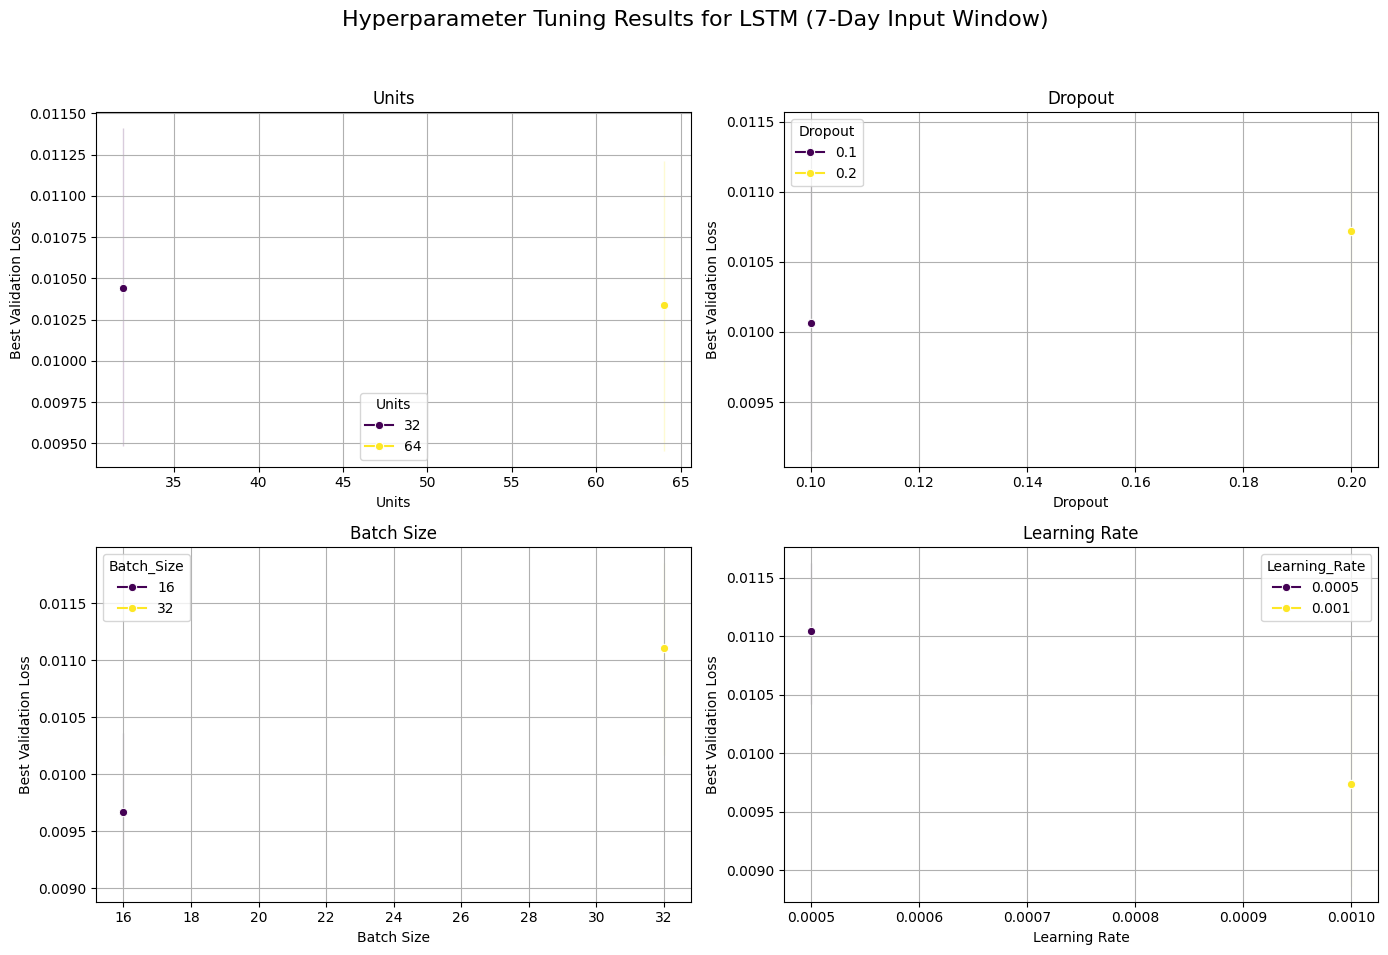

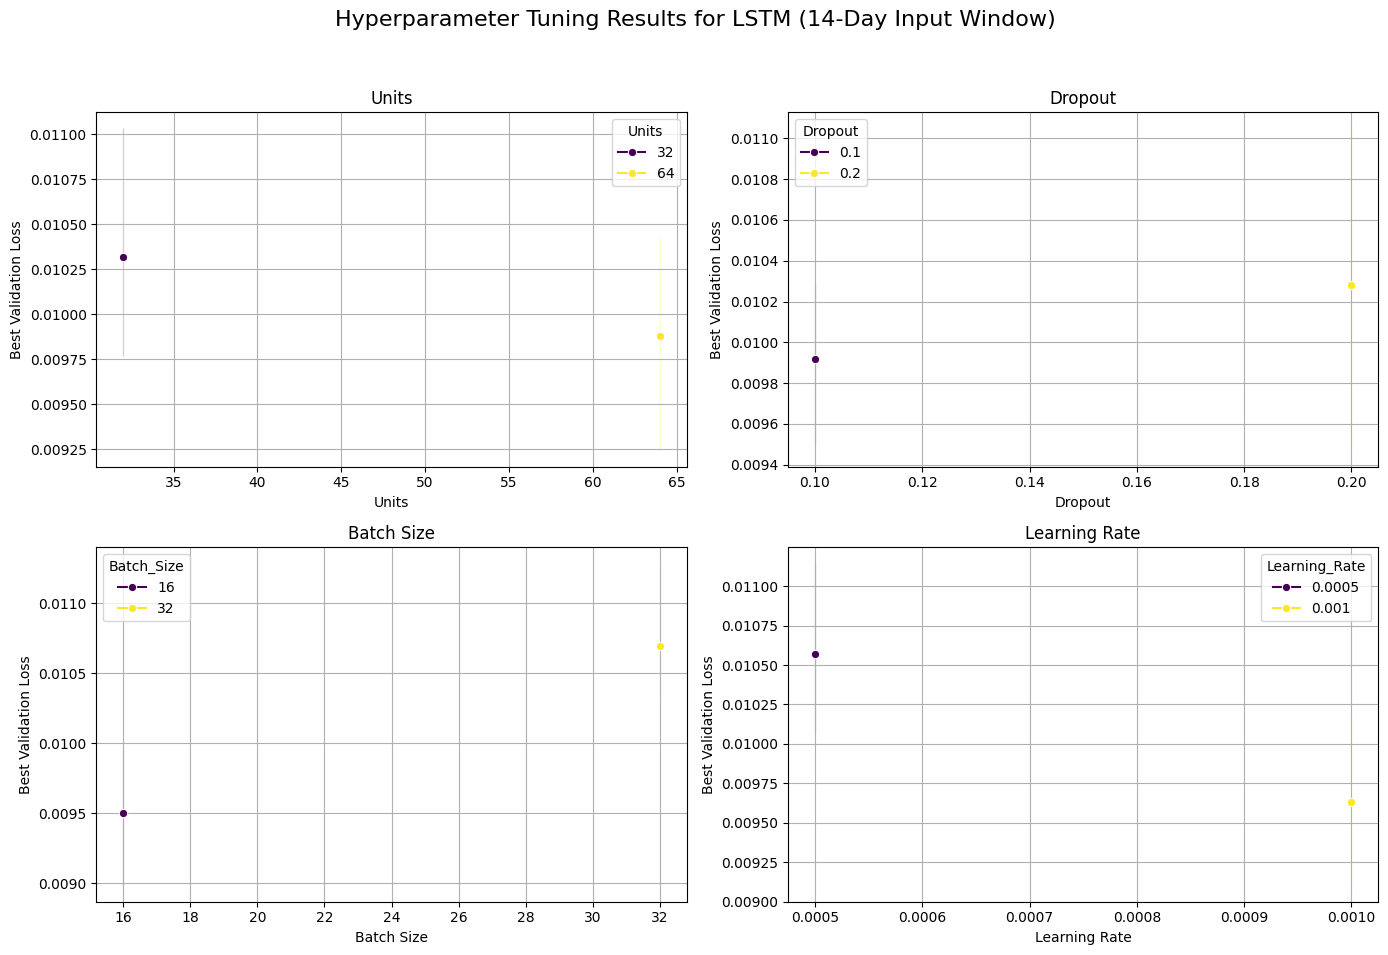

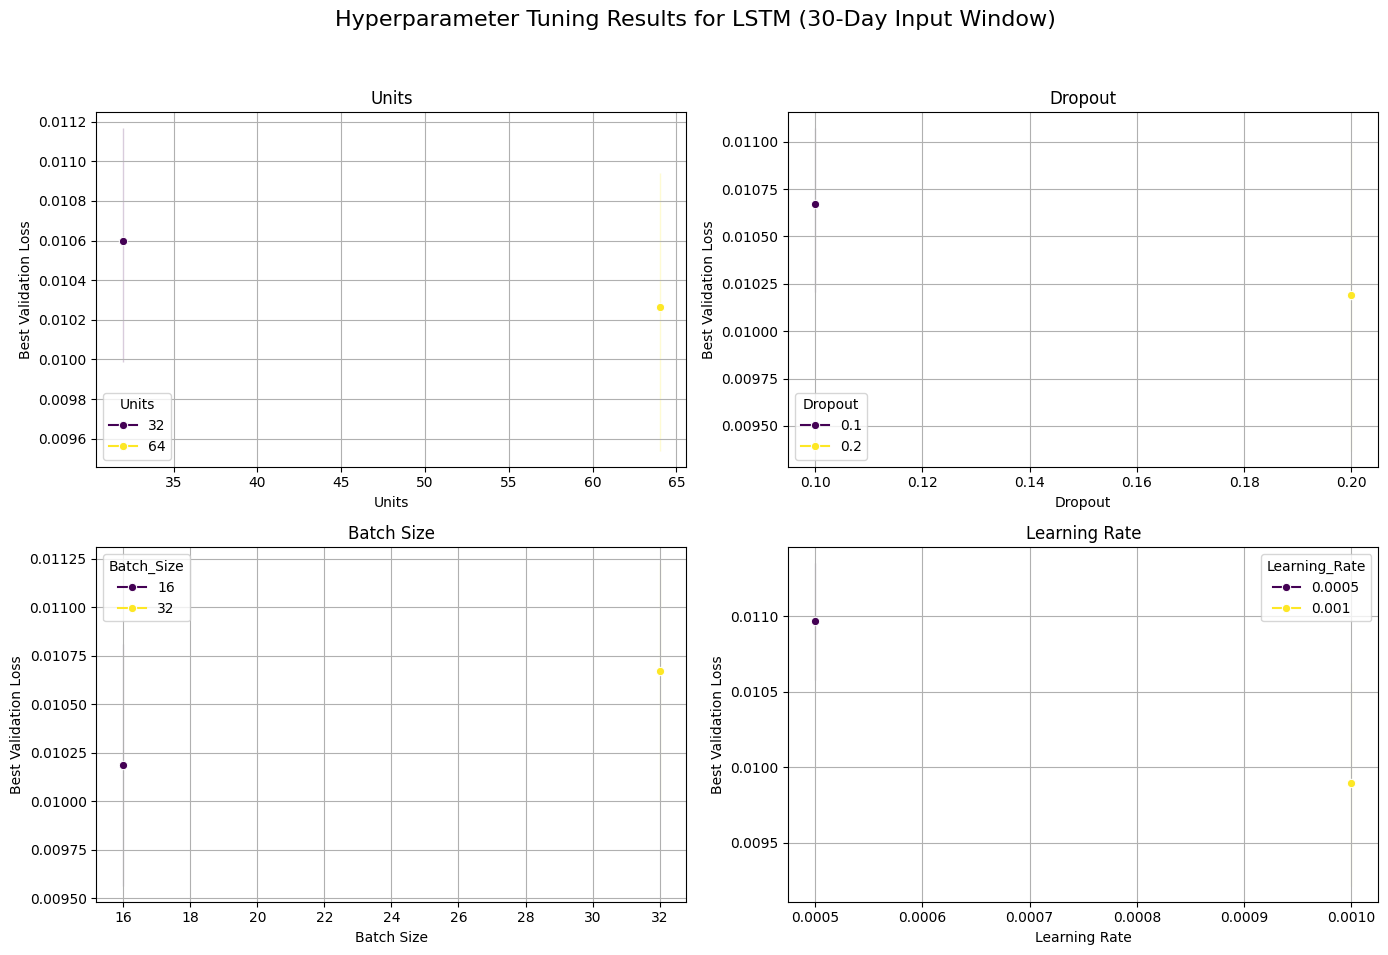

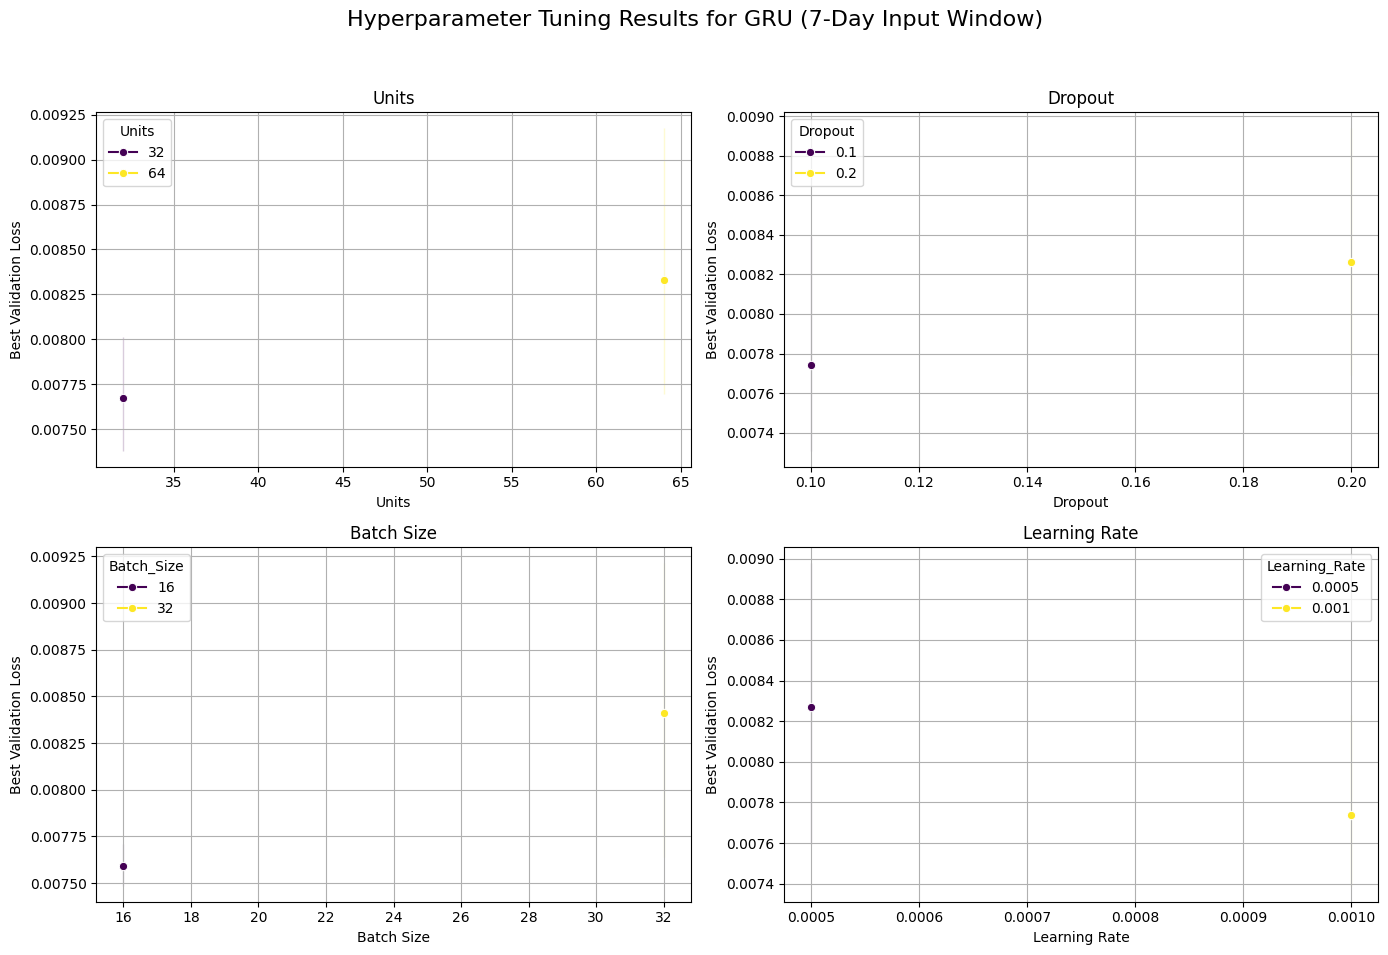

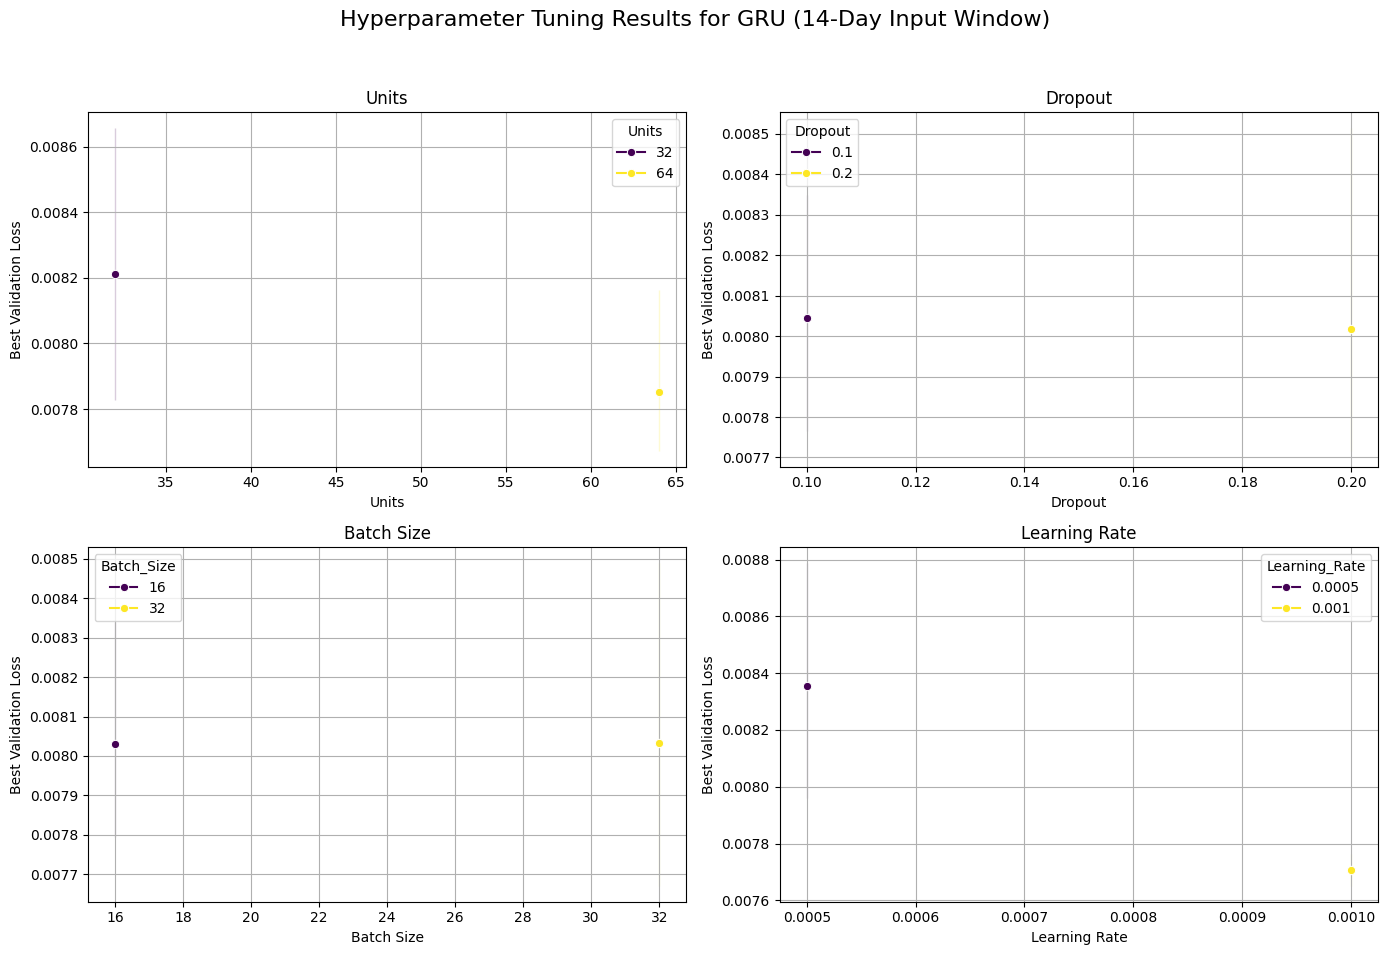

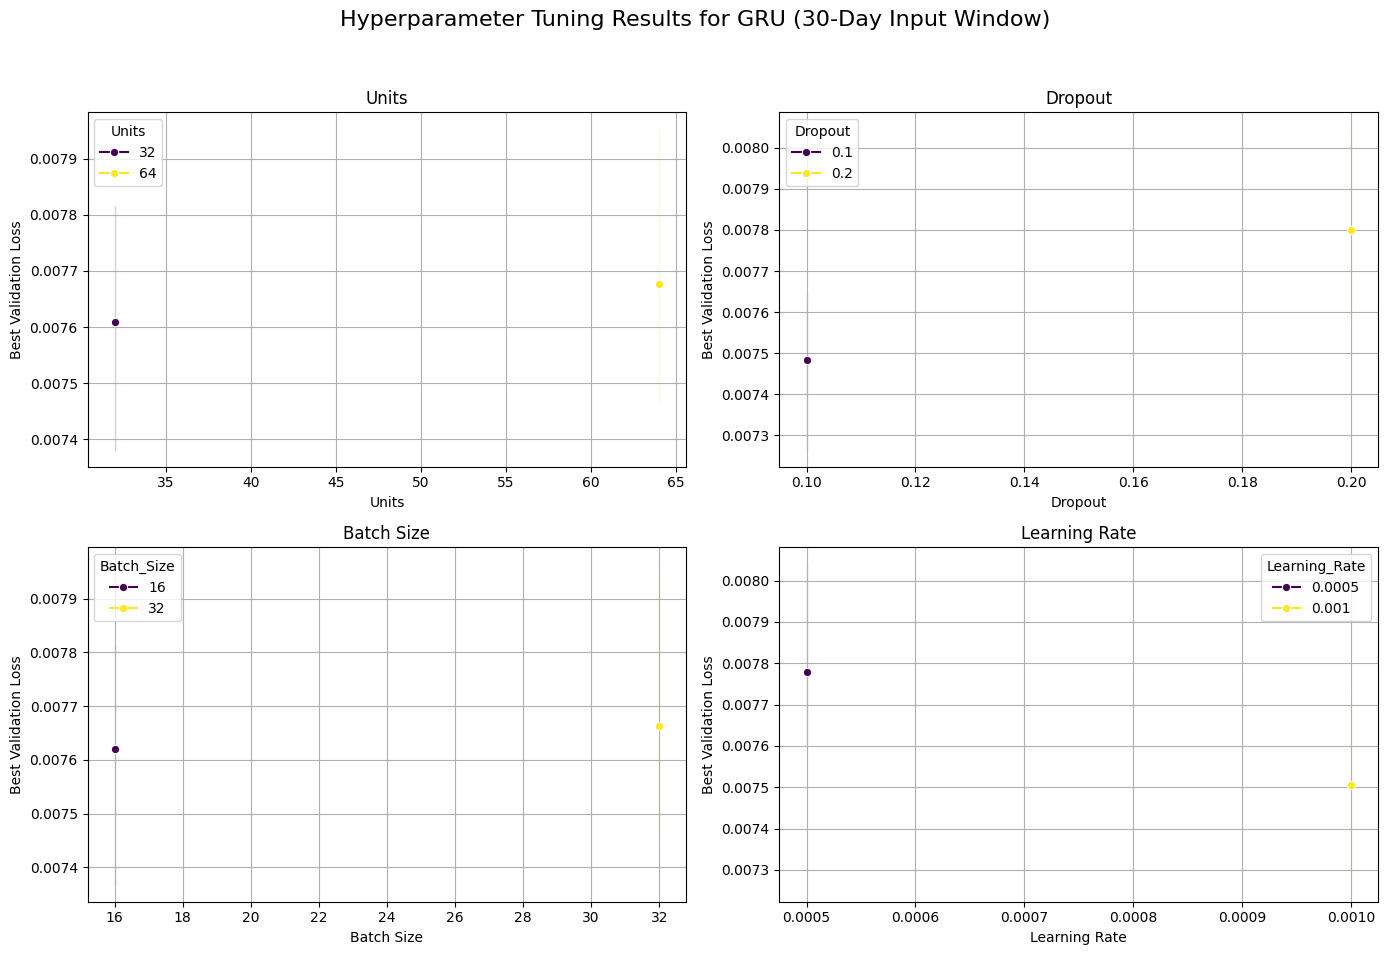

In [28]:
for model_type in ["LSTM", "GRU"]:
    for look_back in LOOK_BACKS:
        subset_df = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Input_Window"] == look_back)
        ]

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Hyperparameter Tuning Results for {model_type} ({look_back}-Day Input Window)', fontsize=16)

        # Plot Units vs. Best_Validation_Loss
        sns.lineplot(ax=axes[0, 0], x='Units', y='Best_Validation_Loss', data=subset_df, marker='o', hue='Units', palette='viridis', legend='full')
        axes[0, 0].set_title('Units')
        axes[0, 0].set_xlabel('Units')
        axes[0, 0].set_ylabel('Best Validation Loss')
        axes[0, 0].grid(True)

        # Plot Dropout vs. Best_Validation_Loss
        sns.lineplot(ax=axes[0, 1], x='Dropout', y='Best_Validation_Loss', data=subset_df, marker='o', hue='Dropout', palette='viridis', legend='full')
        axes[0, 1].set_title('Dropout')
        axes[0, 1].set_xlabel('Dropout')
        axes[0, 1].set_ylabel('Best Validation Loss')
        axes[0, 1].grid(True)

        # Plot Batch_Size vs. Best_Validation_Loss
        sns.lineplot(ax=axes[1, 0], x='Batch_Size', y='Best_Validation_Loss', data=subset_df, marker='o', hue='Batch_Size', palette='viridis', legend='full')
        axes[1, 0].set_title('Batch Size')
        axes[1, 0].set_xlabel('Batch Size')
        axes[1, 0].set_ylabel('Best Validation Loss')
        axes[1, 0].grid(True)

        # Plot Learning_Rate vs. Best_Validation_Loss
        sns.lineplot(ax=axes[1, 1], x='Learning_Rate', y='Best_Validation_Loss', data=subset_df, marker='o', hue='Learning_Rate', palette='viridis', legend='full')
        axes[1, 1].set_title('Learning Rate')
        axes[1, 1].set_xlabel('Learning Rate')
        axes[1, 1].set_ylabel('Best Validation Loss')
        axes[1, 1].grid(True)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## 27. Feature Correlation Heatmap

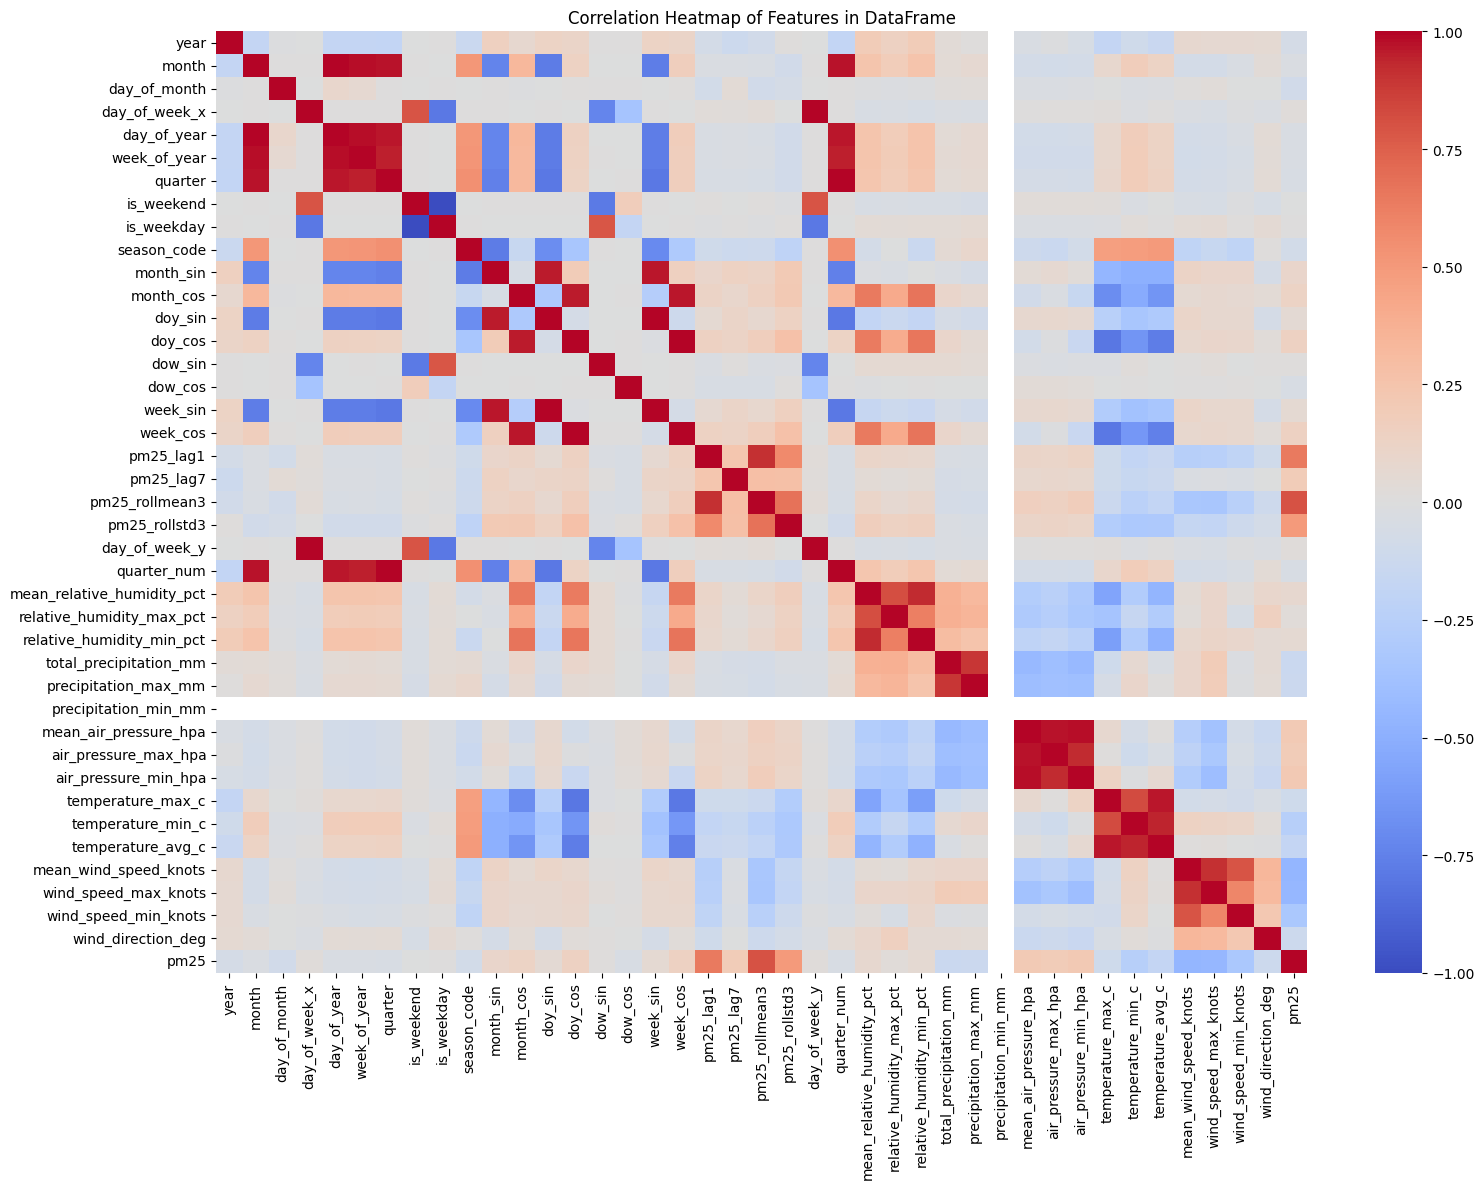

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Heatmap of Features in DataFrame')
plt.tight_layout()
plt.show()

This section introduces Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots, which are critical tools for time series analysis, especially when examining model residuals. If a model's errors are truly random (i.e., the model has captured all the relevant patterns), then the residuals should have no significant autocorrelation. These plots help us detect any remaining patterns or dependencies in the errors. If significant spikes are observed beyond a few lags, it suggests that there's still information in the residuals that the model could potentially learn from, indicating room for improvement.

## 28. Autocorrelation and Partial Autocorrelation of Residuals

To further diagnose the overall best model, we'll plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of its residuals. This helps to identify any remaining patterns or serial correlation in the errors, which would suggest that the model hasn't fully captured the temporal dynamics of the PM2.5 series.

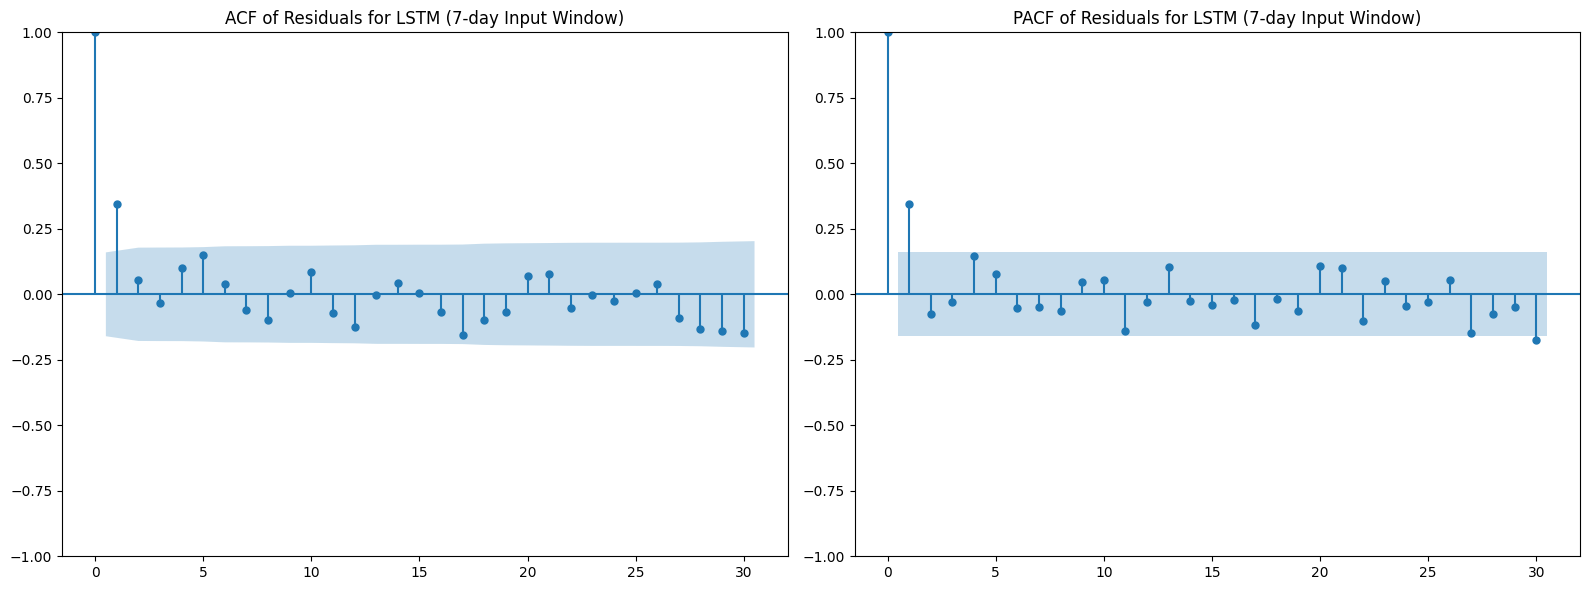

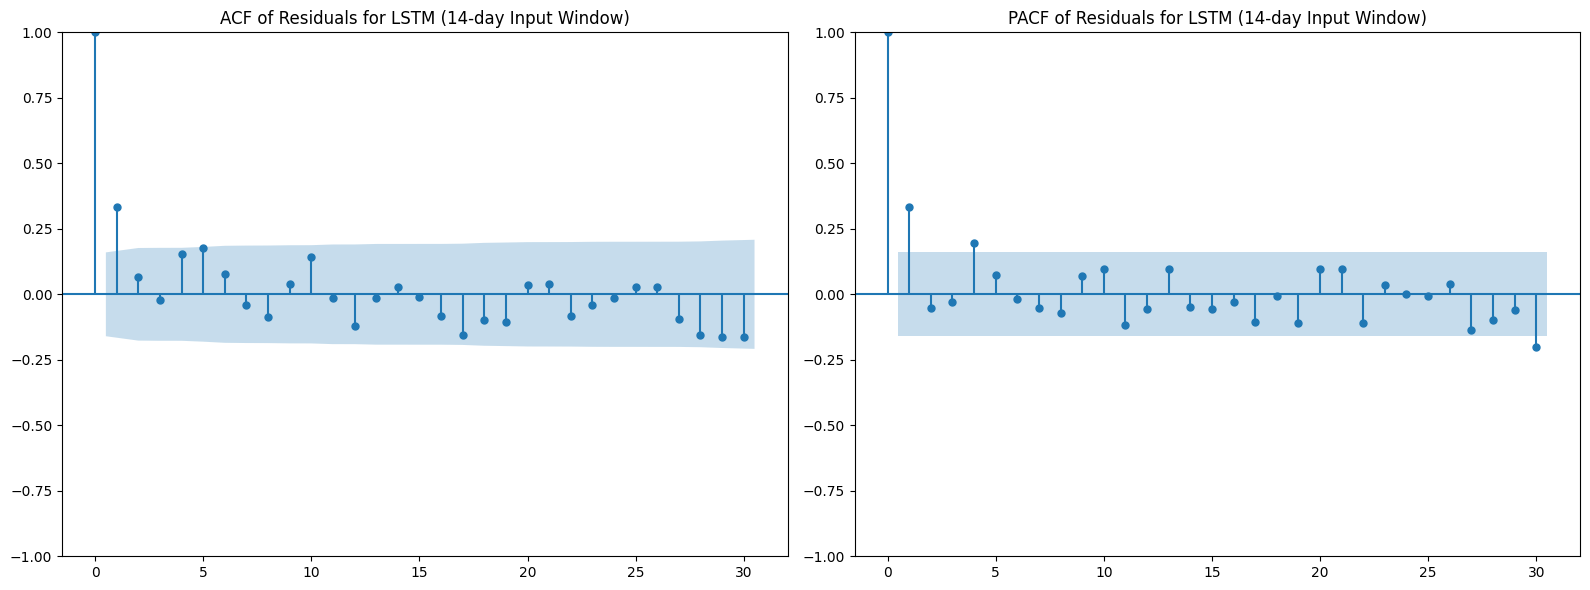

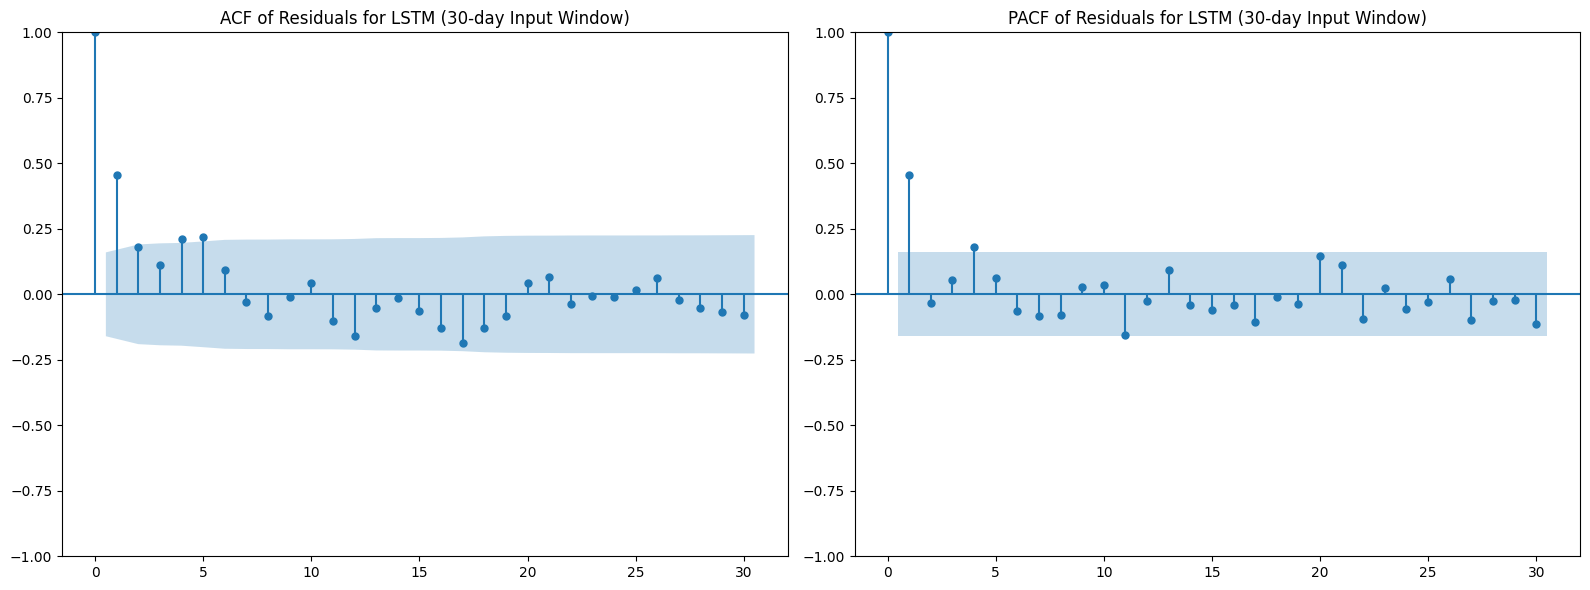

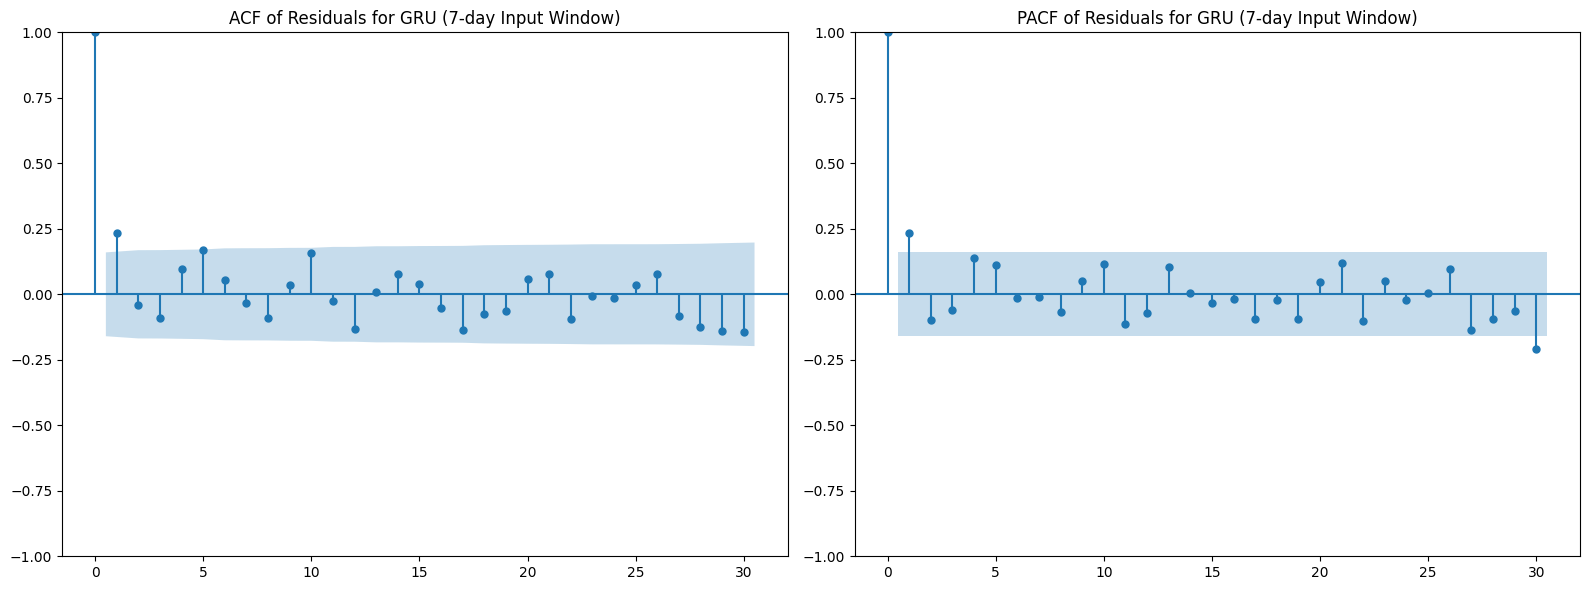

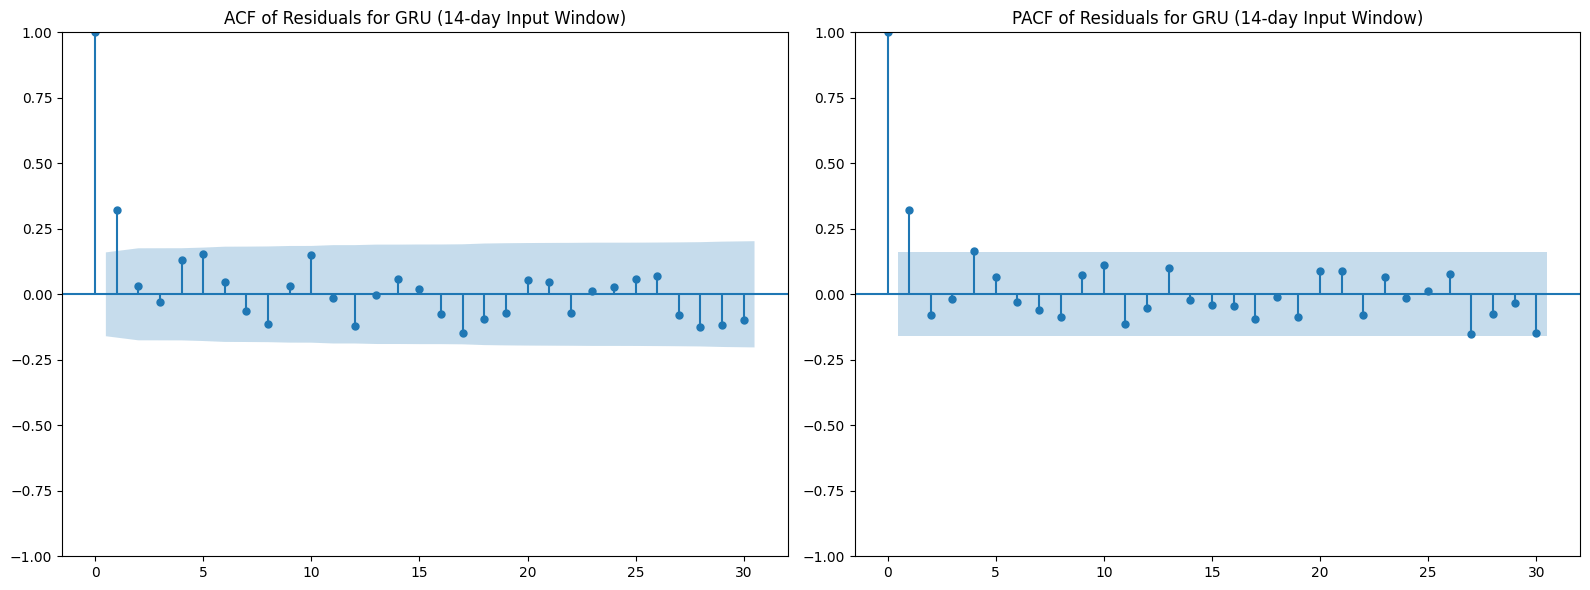

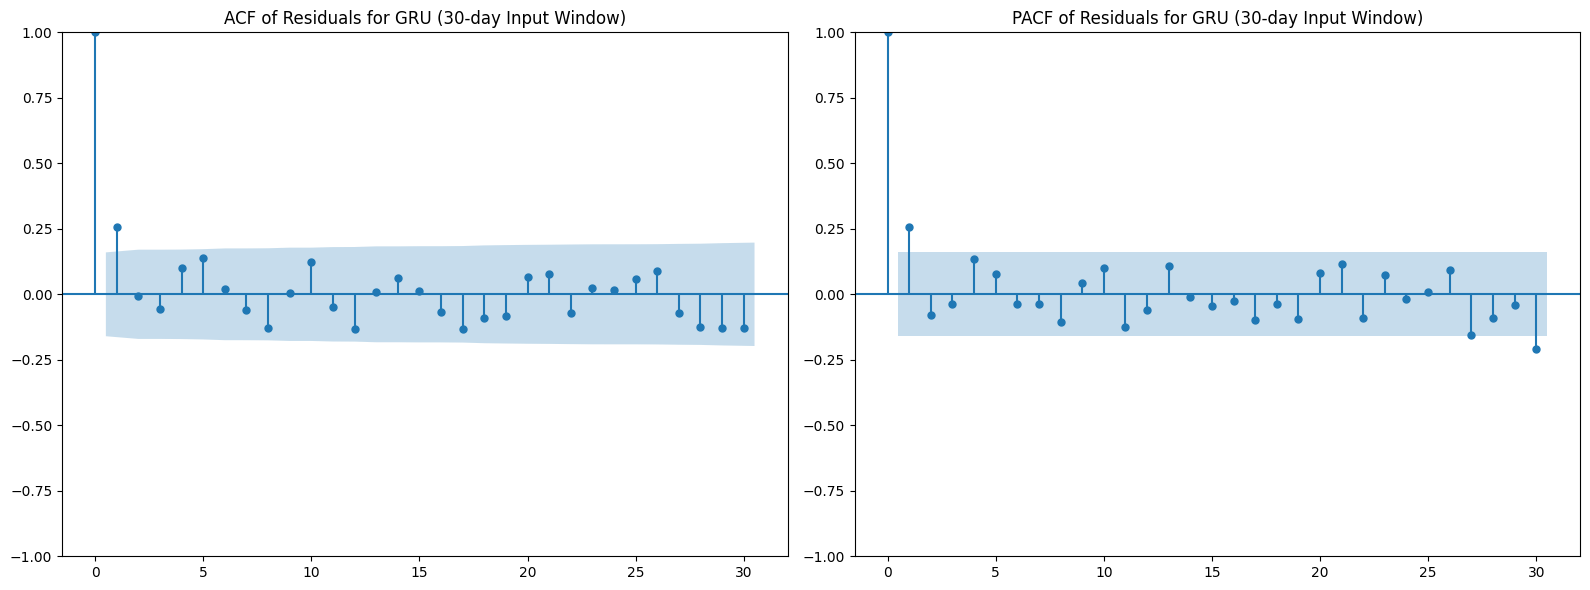

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for look_back in LOOK_BACKS:
        # Retrieve the residuals for the current model and look_back
        current_predictions = predictions[(model_type, look_back)]
        residuals_current = current_predictions['y_true'] - current_predictions['y_pred']

        # Ensure there are enough data points to plot ACF/PACF
        if len(residuals_current) > 1:
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))

            # Plot ACF
            # Use min to avoid lags exceeding half the series length
            lags_to_plot = min(len(residuals_current) // 2 - 1, 30)
            if lags_to_plot < 1:
                print(f"Not enough data for ACF/PACF for {model_type} ({look_back}-day Input Window)")
                plt.close(fig)
                continue

            plot_acf(residuals_current, ax=axes[0], lags=lags_to_plot, alpha=0.05)
            axes[0].set_title(f'ACF of Residuals for {model_type} ({look_back}-day Input Window)')

            # Plot PACF
            plot_pacf(residuals_current, ax=axes[1], lags=lags_to_plot, alpha=0.05)
            axes[1].set_title(f'PACF of Residuals for {model_type} ({look_back}-day Input Window)')

            plt.tight_layout()
            plt.show()

## 29. Application of Agile Methodology
Throughout this project, an agile approach was adopted to manage the development and evaluation of the forecasting models. This involved iterative cycles of data preparation, model development, hyperparameter tuning, and performance evaluation. Key aspects included:

Incremental Development: Building the forecasting pipeline step-by-step, starting from basic data loading and cleaning, then progressing to model building, tuning, and evaluation.


Feedback Loops: Continuously evaluating model performance (e.g., using validation loss during tuning, and comprehensive metrics on the test set) to inform subsequent iterations and improvements.


Adaptability: Being able to adapt the approach based on intermediate results, such as refining hyperparameter ranges or exploring different visualization techniques as insights emerged.


Transparency: Documenting each step and its rationale within the notebook, facilitating understanding and collaboration. This iterative and responsive workflow enabled efficient progress and allowed for continuous refinement of the models and analysis.




## 30. Critical Discussion

### Why LSTM Performed the Way It Did

The LSTM model's performance, particularly its strong showing with a 14-day input window, suggests that it effectively leveraged a moderate amount of historical context. LSTMs are designed to capture long-term dependencies in sequential data, and a 14-day window likely provided enough relevant past information without introducing excessive noise from very distant past observations. The slight deterioration with a 30-day window could indicate that the increased sequence length made the learning task more complex, or that older data points became less relevant for next-day prediction, potentially leading to overfitting or increased training difficulty.

### Why GRU Performed the Way It Did

The GRU model generally showed competitive performance, especially with shorter input windows (e.g., 7-day), sometimes even outperforming LSTM in terms of RMSE for the 7-day window. GRUs are known for their simpler architecture compared to LSTMs, which can make them faster to train and less prone to overfitting on smaller datasets or shorter sequences. The performance pattern of GRU, showing slightly worse or comparable performance with longer input windows, might suggest that while simpler, they may struggle more than LSTMs to retain and selectively use information from very long sequences, especially if the relevant signals are subtle.

### Which Horizon Was Easiest & Hardest

Based on the experiment's design, which consistently predicts the *next day's* PM2.5 value across different input windows, the 'horizon' itself is fixed (next-day). However, the implicit 'horizon' of information gathering changes. From the results (e.g., in `metrics_df`), it appears that predicting the next day with a **14-day input window** was often the 'easiest' in terms of achieving the lowest RMSE, particularly for the LSTM. The **30-day input window** appears to be 'harder' for both models, as performance metrics often worsened compared to the 7-day or 14-day windows. This implies that while more historical data *can* be beneficial, there's a point of diminishing returns where additional, older data may add more noise or irrelevant information than useful signal for a short-term forecast like next-day prediction.

### Is GRU Sufficient Instead of LSTM?

Given the results, GRU models demonstrate strong performance, often comparable to LSTMs, especially with shorter input windows. In scenarios where computational resources are limited, training time is a concern, or the dataset size is moderate, GRU could be a sufficient, and sometimes even preferable, alternative to LSTM. Its simpler gate mechanism can offer a good balance between performance and efficiency. For this next-day forecasting task, the differences in performance between the best LSTM and best GRU were relatively small, suggesting that GRU is indeed a viable and sufficient option.

### Limitations

1.  **Limited Data Period:** The dataset covers a specific time frame, and the models might not generalize well to different periods with distinct seasonality or environmental patterns.
2.  **Single Location:** The data is from a single location (Marylebone). PM2.5 dynamics can be highly localized, and a model trained on this data might not perform effectively in other geographical areas without re-training or adaptation.
3.  **Fixed Input Features:** While comprehensive, the current set of input features might not capture all relevant environmental or socio-economic factors influencing PM2.5 levels. External events (e.g., major industrial activities, wildfires) are not explicitly modeled.
4.  **Hyperparameter Search Scope:** While a hyperparameter grid was used, the search space was limited. Exploring a wider range of hyperparameters or using more advanced tuning techniques (e.g., Bayesian optimization) might yield better results.
5.  **Model Complexity:** LSTM and GRU are powerful but might be overly complex for some patterns, potentially capturing noise. Simpler models might offer better interpretability or efficiency in certain contexts.

### Future Work

1.  **Ensemble Methods:** Explore combining predictions from multiple models (e.g., LSTM, GRU, statistical models) to potentially improve robustness and accuracy.
2.  **Attention Mechanisms:** Incorporate attention mechanisms into the RNN architectures to allow the models to dynamically focus on the most relevant parts of the input sequence.
3.  **External Data Integration:** Investigate the impact of integrating additional external data sources, such as traffic data, industrial activity logs, or real-time meteorological forecasts from external APIs.
4.  **Multi-Output Forecasting:** Extend the models to predict PM2.5 for multiple future days simultaneously, not just the next day, to address longer forecast horizons.
5.  **Transfer Learning:** Explore transfer learning techniques, where models pre-trained on large environmental datasets from various locations could be fine-tuned for new locations with limited data.
6.  **Interpretability:** Develop methods to better interpret the decisions made by the RNN models, understanding which features and historical periods contribute most to predictions.